In [1]:
import numpy as np
import cvxpy as cp
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from scipy.optimize import minimize
from functools import partial
from sklearn.covariance import LedoitWolf
from tensorflow.keras import Model

import CustomModels as cm
import Custom_Layers as cl
import CustomModels_cvxpylayer as cvx
import pipeline

### Useful functions

In [2]:
# Simple NN

def reconstruct_corr(NN_eigvalues, IS_eigvectors):
    S = np.diag(1 / np.sqrt(np.diag(IS_eigvectors @ np.diag(NN_eigvalues) @ IS_eigvectors.T)))
    V = S @ IS_eigvectors
    return V @ np.diag(NN_eigvalues) @ V.T

def reconstruct_cov(NN_eigenvalues, IS_eigenvectors):
    return IS_eigenvectors @ np.diag(NN_eigenvalues) @ IS_eigenvectors.T

def MVP(SigmaInv):
    n=np.shape(SigmaInv)[0]
    return SigmaInv@np.ones((n,1)) / (np.ones((1,n))@SigmaInv@np.ones((n,1)))

def QIS(Sample, ddof=1):
    """
    Compute the Quadratic-Inverse Shrinkage (QIS) estimator for a given sample.
    Parameters:
    Sample (numpy.ndarray): A 2D array where rows represent the stocks and columns represent the time series.
    ddof (int, optional): Degrees of freedom correction for the sample mean. Default is 1: Mean is subtracted.
    Returns:
    numpy.ndarray: The QIS estimator of the covariance matrix.
    Notes:
    - The input sample is expected to be a NumPy array.
    - The function ensures the symmetry of the sample covariance matrix.
    - Eigenvalues are clipped to be non-negative.
    - The function uses a smoothing parameter for the shrinkage estimator.
    - The trace of the covariance matrix is preserved in the final estimator.
    """

    # Y is expected to be a NumPy array
    Sample = Sample.T
    N, p = Sample.shape  # Get dimensions of Y

    # Default setting: if k is None or NaN, set k = 1 (no de-mean)
    if ddof>=1:
        Sample=Sample -np.mean(Sample, axis=0)

    # Vars
    n = N - ddof   # Adjust effective sample size
    c = p / n   # Concentration ratio

    # Compute sample covariance matrix
    sample = np.matmul(Sample.T, Sample) / n
    sample = (sample + sample.T) / 2  # Ensure symmetry

    # Eigenvalue decomposition (use eigh for Hermitian matrix)
    lambda1, u = np.linalg.eigh(sample)
    lambda1 = np.clip(lambda1.real, a_min=0, a_max=None)  # Clip negative eigenvalues to 0

    # Compute Quadratic-Inverse Shrinkage estimator
    h = (min(c**2, 1/c**2)**0.35) / p**0.35  # Smoothing parameter

    # Inverse of (non-null) eigenvalues
    invlambda = 1 / lambda1[max(1, p - n + 1) - 1:p]

    # Calculate Lj and Lj_i (Differences of inverse eigenvalues)
    Lj = np.repeat(invlambda[:, np.newaxis], min(p, n), axis=1)
    Lj_i = Lj - Lj.T

    # Smoothed Stein shrinker (theta) and its conjugate (Htheta)
    Lj_squared = Lj * Lj
    theta = np.mean(Lj * Lj_i / (Lj_i * Lj_i + Lj_squared * h**2), axis=0)
    Htheta = np.mean(Lj * Lj * h / (Lj_i * Lj_i + Lj_squared * h**2), axis=0)
    Atheta2 = theta**2 + Htheta**2  # Squared amplitude

    # Shrink eigenvalues based on p and n
    if p <= n:
        delta = 1 / ((1 - c)**2 * invlambda + 2 * c * (1 - c) * invlambda * theta + c**2 * invlambda * Atheta2)
    else:
        delta0 = 1 / ((c - 1) * np.mean(invlambda))  # Shrinkage of null eigenvalues
        delta = np.concatenate((
            np.full(p - n, delta0), 
            1 / (invlambda * Atheta2)
        ))

    # Preserve the trace
    deltaQIS = delta * (np.sum(lambda1) / np.sum(delta))

    # Reconstruct covariance matrix
    sigmahat = np.matmul(u, np.matmul(np.diag(deltaQIS), u.T))

    return sigmahat

def cov_to_corr(cov):
    D_inv = np.diag(1 / np.sqrt(np.diag(cov)))
    return D_inv @ cov @ D_inv
def corr_to_cov(corr, var):
    D = np.diag(np.sqrt(var))
    return D @ corr @ D
def invcorr_to_invcov(invcorr, var):
    D_inv = np.diag(1 / np.sqrt(var))
    return D_inv @ invcorr @ D_inv

def training(loss, opt, epochs, train_ds, steps_per_epoch, val_ds, validation_steps):

    simple_cnn = Simple_CNN(loss, opt)
    simple_cnn.train(True, train_ds, steps_per_epoch, epochs)

    val_loss = simple_cnn.validate(val_ds, validation_steps)
    print(f'Validation loss = {val_loss}')

    return simple_cnn

def nn_test_training(N_test, L_add_epochs, filters, kernel_size, loss, train_ds, steps_per_epoch, val_ds, validation_steps):

    N_epochs = len(L_add_epochs)
    train_loss_full, val_loss_full = np.empty((N_test,N_epochs)), np.empty((N_test,N_epochs))

    for i in range(N_test):

        simple_cnn = Simple_CNN(filters, kernel_size, loss)
        simple_cnn.set_model()

        for j in range(N_epochs):
            train_loss_full[i,j] = simple_cnn.train(False, train_ds, steps_per_epoch, L_add_epochs[j])
            val_loss_full[i,j] = simple_cnn.validate(val_ds, validation_steps)
    
    return np.cumsum(L_add_epochs), train_loss_full, val_loss_full

def nn_test_plot(L_epochs, train_loss_full, val_loss_full):

    N_test = np.shape(train_loss_full)[0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

    for i in range(N_test):
        axes[0].plot(L_epochs,train_loss_full[i])
        axes[1].plot(L_epochs,val_loss_full[i])

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training loss')
    #axes[0].set_yscale('log')
    axes[0].scatter(L_epochs,np.mean(train_loss_full,axis=0),color='purple')
    axes[0].grid()
    
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation loss')
    #axes[1].set_yscale('log')
    axes[1].scatter(L_epochs,np.mean(val_loss_full,axis=0),color='purple')
    axes[1].grid()
    
    plt.suptitle('Loss Evolution through Epochs')
    plt.tight_layout()
    plt.show()

def test_distances_calculations(kind, nn, generator, N_points):

    eig_oracle_to_MLE, eig_oracle_to_NN, eig_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)

    if kind == 'corr':

        corr_oracle_to_MLE, corr_oracle_to_NN, corr_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)
        cov_oracle_to_MLE, cov_oracle_to_NN, cov_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)
        inv_oracle_to_MLE, inv_oracle_to_NN, inv_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)

        for i in range(N_points):
        
            x_time_series, y_time_series, n_stock = generator()

            x_val_corr = np.corrcoef(x_time_series.T)
            x_val_var = np.var(x_time_series,axis=0,ddof=1)
            x_val_cov = corr_to_cov(x_val_corr,x_val_var)
            y_val_corr = np.corrcoef(y_time_series.T)
            y_val_cov = np.cov(y_time_series.T)
            y_val_eig = np.linalg.eigh(y_val_corr)[0]
            y_val_inv = np.linalg.pinv(y_val_cov)

            MLE_eigenelts = np.linalg.eigh(x_val_corr)
            MLE_correlation = x_val_corr
            MLE_covariance = x_val_cov
            MLE_inv = np.linalg.pinv(x_val_cov)
            QIS_covariance = QIS(x_time_series.T)
            QIS_correlation = cov_to_corr(QIS_covariance)
            QIS_eig = np.linalg.eigh(QIS_correlation)[0]
            QIS_inv = np.linalg.pinv(QIS_covariance)
            NN_eig = nn.call(MLE_eigenelts[0])
            NN_correlation = reconstruct_corr(NN_eig, MLE_eigenelts[1])
            NN_covariance = corr_to_cov(NN_correlation, x_val_var)
            NN_inv = np.linalg.pinv(NN_covariance)

            eig_oracle_to_MLE[i] = np.sum((y_val_eig - MLE_eigenelts[0])**2) / n_stock
            eig_oracle_to_NN[i] = np.sum((y_val_eig - NN_eig)**2) / n_stock
            eig_oracle_to_QIS[i] = np.sum((y_val_eig - QIS_eig)**2) / n_stock

            corr_oracle_to_MLE[i] = np.sum((y_val_corr - MLE_correlation)**2) / n_stock**2
            corr_oracle_to_NN[i] = np.sum((y_val_corr - NN_correlation)**2) / n_stock**2
            corr_oracle_to_QIS[i] = np.sum((y_val_corr - QIS_correlation)**2) / n_stock**2

            cov_oracle_to_MLE[i] = np.sum((y_val_cov - MLE_covariance)**2) / n_stock**2
            cov_oracle_to_NN[i] = np.sum((y_val_cov - NN_covariance)**2) / n_stock**2
            cov_oracle_to_QIS[i] = np.sum((y_val_cov - QIS_covariance)**2) / n_stock**2

            inv_oracle_to_MLE[i] = np.sum((y_val_inv - MLE_inv)**2) / n_stock**2
            inv_oracle_to_NN[i] = np.sum((y_val_inv - NN_inv)**2) / n_stock**2
            inv_oracle_to_QIS[i] = np.sum((y_val_inv - QIS_inv)**2) / n_stock**2

        return eig_oracle_to_NN, eig_oracle_to_MLE, eig_oracle_to_QIS, corr_oracle_to_NN, corr_oracle_to_MLE, corr_oracle_to_QIS, cov_oracle_to_NN, cov_oracle_to_MLE, cov_oracle_to_QIS, inv_oracle_to_NN, inv_oracle_to_MLE, inv_oracle_to_QIS
    
    elif kind == 'cov':

        cov_oracle_to_MLE, cov_oracle_to_NN, cov_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)
        inv_oracle_to_MLE, inv_oracle_to_NN, inv_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)

        for i in range(N_points):
        
            x_time_series, y_time_series, n_stock = generator()

            x_val_cov = np.cov(x_time_series.T)
            y_val_cov = np.cov(y_time_series.T)
            y_val_eig = np.linalg.eigh(y_val_cov)[0]
            y_val_inv = np.linalg.pinv(y_val_cov)

            MLE_eigenelts = np.linalg.eigh(x_val_cov)
            MLE_covariance = x_val_cov
            MLE_inv = np.linalg.pinv(x_val_cov)
            NN_eig = nn.call(MLE_eigenelts[0])
            NN_covariance = reconstruct_cov(NN_eig,MLE_eigenelts[1])
            NN_inv = np.linalg.pinv(NN_covariance)
            QIS_covariance = QIS(x_time_series.T)
            QIS_eig = np.linalg.eigh(QIS_covariance)[0]
            QIS_inv = np.linalg.pinv(QIS_covariance)

            eig_oracle_to_MLE[i] = np.sum((y_val_eig - MLE_eigenelts[0])**2) / n_stock
            eig_oracle_to_NN[i] = np.sum((y_val_eig - NN_eig)**2) / n_stock
            eig_oracle_to_QIS[i] = np.sum((y_val_eig - QIS_eig)**2) / n_stock

            cov_oracle_to_MLE[i] = np.sum((y_val_cov - MLE_covariance)**2) / n_stock**2
            cov_oracle_to_NN[i] = np.sum((y_val_cov - NN_covariance)**2) / n_stock**2
            cov_oracle_to_QIS[i] = np.sum((y_val_cov - QIS_covariance)**2) / n_stock**2

            inv_oracle_to_MLE[i] = np.sum((y_val_inv - MLE_inv)**2) / n_stock**2
            inv_oracle_to_NN[i] = np.sum((y_val_inv - NN_inv)**2) / n_stock**2
            inv_oracle_to_QIS[i] = np.sum((y_val_inv - QIS_inv)**2) / n_stock**2

        return eig_oracle_to_NN, eig_oracle_to_MLE, eig_oracle_to_QIS, cov_oracle_to_NN, cov_oracle_to_MLE, cov_oracle_to_QIS, inv_oracle_to_NN, inv_oracle_to_MLE, inv_oracle_to_QIS
    
    elif kind == 'invcorr':

        invcorr_oracle_to_MLE, invcorr_oracle_to_NN, invcorr_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)
        invcov_oracle_to_MLE, invcov_oracle_to_NN, invcov_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)

        for i in range(N_points):
        
            x_time_series, y_time_series, n_stock = generator()

            x_val_corr = np.corrcoef(x_time_series.T)
            x_val_cov = np.cov(x_time_series.T)
            x_val_var = np.var(x_time_series,axis=0,ddof=1)
            y_val_corr = np.corrcoef(y_time_series.T)
            y_val_eig = 1 / np.linalg.eigh(y_val_corr)[0]
            y_val_invcorr = np.linalg.pinv(y_val_corr)
            y_val_invcov = np.linalg.pinv(np.cov(y_time_series.T))

            MLE_eigenelts = np.linalg.eigh(x_val_corr)
            MLE_invcorr = np.linalg.pinv(x_val_corr)
            MLE_invcov = np.linalg.pinv(x_val_cov)
            NN_eig = nn.call(1 / MLE_eigenelts[0])
            NN_invcorr = reconstruct_corr(NN_eig, MLE_eigenelts[1])
            NN_invcov = invcorr_to_invcov(NN_invcorr, x_val_var)
            QIS_covariance = QIS(x_time_series.T)
            QIS_correlation = cov_to_corr(QIS_covariance)
            QIS_eig = 1 / np.linalg.eigh(QIS_correlation)[0]
            QIS_invcorr = np.linalg.pinv(QIS_correlation)
            QIS_invcov = np.linalg.pinv(QIS_covariance)

            eig_oracle_to_MLE[i] = np.sum((y_val_eig - (1/MLE_eigenelts[0]))**2) / n_stock
            eig_oracle_to_NN[i] = np.sum((y_val_eig - NN_eig)**2) / n_stock
            eig_oracle_to_QIS[i] = np.sum((y_val_eig - QIS_eig)**2) / n_stock

            invcorr_oracle_to_MLE[i] = np.sum((y_val_invcorr - MLE_invcorr)**2) / n_stock**2
            invcorr_oracle_to_NN[i] = np.sum((y_val_invcorr - NN_invcorr)**2) / n_stock**2
            invcorr_oracle_to_QIS[i] = np.sum((y_val_invcorr - QIS_invcorr)**2) / n_stock**2

            invcov_oracle_to_MLE[i] = np.sum((y_val_invcov - MLE_invcov)**2) / n_stock**2
            invcov_oracle_to_NN[i] = np.sum((y_val_invcov - NN_invcov)**2) / n_stock**2
            invcov_oracle_to_QIS[i] = np.sum((y_val_invcov - QIS_invcov)**2) / n_stock**2

        return eig_oracle_to_NN, eig_oracle_to_MLE, eig_oracle_to_QIS, invcorr_oracle_to_NN, invcorr_oracle_to_MLE, invcorr_oracle_to_QIS, invcov_oracle_to_NN, invcov_oracle_to_MLE, invcov_oracle_to_QIS
    
    elif kind == 'invcov':

        inv_oracle_to_MLE, inv_oracle_to_NN, inv_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)

        for i in range(N_points):
        
            x_time_series, y_time_series, n_stock = generator()

            x_val_cov = np.cov(x_time_series.T)
            y_val_cov = np.cov(y_time_series.T)
            y_val_eig = 1 / np.linalg.eigh(y_val_cov)[0]
            y_val_inv = np.linalg.pinv(y_val_cov)

            MLE_eigenelts = np.linalg.eigh(x_val_cov)
            MLE_inv = np.linalg.pinv(x_val_cov)
            NN_eig = nn.call(1 / MLE_eigenelts[0])
            NN_inv = reconstruct_cov(NN_eig,MLE_eigenelts[1])
            QIS_covariance = QIS(x_time_series.T)
            QIS_eig = 1 / np.linalg.eigh(QIS_covariance)[0]
            QIS_inv = np.linalg.pinv(QIS_covariance)

            eig_oracle_to_MLE[i] = np.sum((y_val_eig - (1/MLE_eigenelts[0]))**2) / n_stock
            eig_oracle_to_NN[i] = np.sum((y_val_eig - NN_eig)**2) / n_stock
            eig_oracle_to_QIS[i] = np.sum((y_val_eig - QIS_eig)**2) / n_stock

            inv_oracle_to_MLE[i] = np.sum((y_val_inv - MLE_inv)**2) / n_stock**2
            inv_oracle_to_NN[i] = np.sum((y_val_inv - NN_inv)**2) / n_stock**2
            inv_oracle_to_QIS[i] = np.sum((y_val_inv - QIS_inv)**2) / n_stock**2

        return eig_oracle_to_NN, eig_oracle_to_MLE, eig_oracle_to_QIS, invcov_oracle_to_NN, invcov_oracle_to_MLE, invcov_oracle_to_QIS

def test_distances_plot_corr(benchmark, eig_oracle_to_NN, eig_oracle_to_benchmark, corr_oracle_to_NN, corr_oracle_to_benchmark, cov_oracle_to_NN, cov_oracle_to_benchmark, inv_oracle_to_NN, inv_oracle_to_benchmark):

    n_val = np.shape(eig_oracle_to_benchmark)[0]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2 rows, 2 columns

    axes[0,0].scatter(eig_oracle_to_NN, eig_oracle_to_benchmark, s=5, label='Samples')
    eig_x_bar = np.mean(eig_oracle_to_NN)
    eig_y_bar = np.mean(eig_oracle_to_benchmark)
    axes[0,0].scatter(eig_x_bar, eig_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[0,0].set_xlabel('Oracle to NN')
    axes[0,0].set_ylabel(f'Oracle to {benchmark}')
    axes[0,0].set_title('Distance to Correlation Eigenvalues')
    axes[0,0].set_xscale('log')
    axes[0,0].set_yscale('log')
    axes[0,0].grid()

    axes[0,1].scatter(corr_oracle_to_NN, corr_oracle_to_benchmark, s=5, label='Samples')
    corr_x_bar = np.mean(corr_oracle_to_NN)
    corr_y_bar = np.mean(corr_oracle_to_benchmark)
    axes[0,1].scatter(corr_x_bar, corr_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[0,1].set_xlabel('Oracle to NN')
    axes[0,1].set_ylabel(f'Oracle to {benchmark}')
    axes[0,1].set_title('Distance to Correlation Matrix')
    axes[0,1].set_xscale('log')
    axes[0,1].set_yscale('log')
    axes[0,1].grid()

    axes[1,0].scatter(cov_oracle_to_NN, cov_oracle_to_benchmark, s=5, label='Samples')
    cov_x_bar = np.mean(cov_oracle_to_NN)
    cov_y_bar = np.mean(cov_oracle_to_benchmark)
    axes[1,0].scatter(cov_x_bar, cov_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[1,0].set_xlabel('Oracle to NN')
    axes[1,0].set_ylabel(f'Oracle to {benchmark}')
    axes[1,0].set_title('Distance to Covariance Matrix')
    axes[1,0].set_xscale('log')
    axes[1,0].set_yscale('log')
    axes[1,0].grid()

    axes[1,1].scatter(inv_oracle_to_NN, inv_oracle_to_benchmark, s=5, label='Samples')
    inv_x_bar = np.mean(inv_oracle_to_NN)
    inv_y_bar = np.mean(inv_oracle_to_benchmark)
    axes[1,1].scatter(inv_x_bar, inv_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[1,1].set_xlabel('Oracle to NN')
    axes[1,1].set_ylabel(f'Oracle to {benchmark}')
    axes[1,1].set_title('Distance to Inverse Covariance')
    axes[1,1].set_xscale('log')
    axes[1,1].set_yscale('log')
    axes[1,1].grid()

    for ax in axes.ravel():
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        # Keep limits valid for log scale
        lo = max(min(x_min, y_min), np.finfo(float).tiny)
        hi = max(x_max, y_max)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.plot([lo, hi], [lo, hi], 'r-', label='y = x')
        ax.legend()

    plt.suptitle(f'NN vs {benchmark}')
    plt.tight_layout()
    plt.show()

    print('Distance to Correlation Eigenvalues :')
    eig_NN_better = np.sum(eig_oracle_to_benchmark - eig_oracle_to_NN > 0)
    eig_prop = int(100 * eig_NN_better / n_val)
    eig_pval = binomtest(eig_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {eig_prop} % of the samples \n* p-value = {eig_pval}')
    print(f'Distance to Correlation Matrix :')
    corr_NN_better = np.sum(corr_oracle_to_benchmark - corr_oracle_to_NN > 0)
    corr_prop = int(100 * corr_NN_better / n_val)
    corr_pval = binomtest(corr_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {corr_prop} % of the samples \n* p-value = {corr_pval}')
    print(f'Distance to Covariance Matrix :')
    cov_NN_better = np.sum(cov_oracle_to_benchmark - cov_oracle_to_NN > 0)
    cov_prop = int(100 * cov_NN_better / n_val)
    cov_pval = binomtest(cov_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {cov_prop} % of the samples \n* p-value = {cov_pval}')
    print(f'Distance to Inverse Covariance Matrix :')
    inv_NN_better = np.sum(inv_oracle_to_benchmark - inv_oracle_to_NN > 0)
    inv_prop = int(100 * inv_NN_better / n_val)
    inv_pval = binomtest(inv_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {inv_prop} % of the samples \n* p-value = {inv_pval}')
def test_distances_plot_cov(benchmark, eig_oracle_to_NN, eig_oracle_to_benchmark, cov_oracle_to_NN, cov_oracle_to_benchmark, inv_oracle_to_NN, inv_oracle_to_benchmark):

    n_val = np.shape(eig_oracle_to_benchmark)[0]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 3 columns

    axes[0].scatter(eig_oracle_to_NN, eig_oracle_to_benchmark, s=5, label='Samples')
    eig_x_bar = np.mean(eig_oracle_to_NN)
    eig_y_bar = np.mean(eig_oracle_to_benchmark)
    axes[0].scatter(eig_x_bar, eig_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[0].set_xlabel('Oracle to NN')
    axes[0].set_ylabel(f'Oracle to {benchmark}')
    axes[0].set_title('Distance to Covariance Eigenvalues')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].grid()

    axes[1].scatter(cov_oracle_to_NN, cov_oracle_to_benchmark, s=5, label='Samples')
    cov_x_bar = np.mean(cov_oracle_to_NN)
    cov_y_bar = np.mean(cov_oracle_to_benchmark)
    axes[1].scatter(cov_x_bar, cov_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[1].set_xlabel('Oracle to NN')
    axes[1].set_ylabel(f'Oracle to {benchmark}')
    axes[1].set_title('Distance to Covariance Matrix')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].grid()

    axes[2].scatter(inv_oracle_to_NN, inv_oracle_to_benchmark, s=5, label='Samples')
    inv_x_bar = np.mean(inv_oracle_to_NN)
    inv_y_bar = np.mean(inv_oracle_to_benchmark)
    axes[2].scatter(inv_x_bar, inv_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[2].set_xlabel('Oracle to NN')
    axes[2].set_ylabel(f'Oracle to {benchmark}')
    axes[2].set_title('Distance to Inverse Covariance')
    axes[2].set_xscale('log')
    axes[2].set_yscale('log')
    axes[2].grid()

    for ax in axes.ravel():
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        # Keep limits valid for log scale
        lo = max(min(x_min, y_min), np.finfo(float).tiny)
        hi = max(x_max, y_max)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.plot([lo, hi], [lo, hi], 'r-', label='y = x')
        ax.legend()

    plt.suptitle(f'NN vs {benchmark}')
    plt.tight_layout()
    plt.show()

    print('Distance to Covariance Eigenvalues :')
    eig_NN_better = np.sum(eig_oracle_to_benchmark - eig_oracle_to_NN > 0)
    eig_prop = int(100 * eig_NN_better / n_val)
    eig_pval = binomtest(eig_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {eig_prop} % of the samples \n* p-value = {eig_pval}')
    print(f'Distance to Covariance Matrix :')
    cov_NN_better = np.sum(cov_oracle_to_benchmark - cov_oracle_to_NN > 0)
    cov_prop = int(100 * cov_NN_better / n_val)
    cov_pval = binomtest(cov_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {cov_prop} % of the samples \n* p-value = {cov_pval}')
    print(f'Distance to Inverse Covariance :')
    inv_NN_better = np.sum(inv_oracle_to_benchmark - inv_oracle_to_NN > 0)
    inv_prop = int(100 * inv_NN_better / n_val)
    inv_pval = binomtest(inv_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {inv_prop} % of the samples \n* p-value = {inv_pval}')
def test_distances_plot_invcorr(benchmark, eig_oracle_to_NN, eig_oracle_to_benchmark, invcorr_oracle_to_NN, invcorr_oracle_to_benchmark, invcov_oracle_to_NN, invcov_oracle_to_benchmark):

    n_val = np.shape(eig_oracle_to_benchmark)[0]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 3 columns

    axes[0].scatter(eig_oracle_to_NN, eig_oracle_to_benchmark, s=5, label='Samples')
    eig_x_bar = np.mean(eig_oracle_to_NN)
    eig_y_bar = np.mean(eig_oracle_to_benchmark)
    axes[0].scatter(eig_x_bar, eig_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[0].set_xlabel('Oracle to NN')
    axes[0].set_ylabel(f'Oracle to {benchmark}')
    axes[0].set_title('Distance to Inverse Eigenvalues')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].grid()

    axes[1].scatter(invcorr_oracle_to_NN, invcorr_oracle_to_benchmark, s=5, label='Samples')
    invcorr_x_bar = np.mean(invcorr_oracle_to_NN)
    invcorr_y_bar = np.mean(invcorr_oracle_to_benchmark)
    axes[1].scatter(invcorr_x_bar, invcorr_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[1].set_xlabel('Oracle to NN')
    axes[1].set_ylabel(f'Oracle to {benchmark}')
    axes[1].set_title(f'Distance to Inverse Correlation Matrix')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].grid()

    axes[2].scatter(invcov_oracle_to_NN, invcov_oracle_to_benchmark, s=5, label='Samples')
    invcov_x_bar = np.mean(invcov_oracle_to_NN)
    invcov_y_bar = np.mean(invcov_oracle_to_benchmark)
    axes[2].scatter(invcov_x_bar, invcov_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[2].set_xlabel('Oracle to NN')
    axes[2].set_ylabel(f'Oracle to {benchmark}')
    axes[2].set_title(f'Distance to Inverse Covariance Matrix')
    axes[2].set_xscale('log')
    axes[2].set_yscale('log')
    axes[2].grid()

    for ax in axes.ravel():
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        # Keep limits valid for log scale
        lo = max(min(x_min, y_min), np.finfo(float).tiny)
        hi = max(x_max, y_max)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.plot([lo, hi], [lo, hi], 'r-', label='y = x')
        ax.legend()

    plt.suptitle(f'NN vs {benchmark}')
    plt.tight_layout()
    plt.show()

    print('Distance to Inverse Eigenvalues :')
    eig_NN_better = np.sum(eig_oracle_to_benchmark - eig_oracle_to_NN > 0)
    eig_prop = int(100 * eig_NN_better / n_val)
    eig_pval = binomtest(eig_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {eig_prop} % of the samples \n* p-value = {eig_pval}')
    print(f'Distance to Inverse Correlation Matrix :')
    invcorr_NN_better = np.sum(invcorr_oracle_to_benchmark - invcorr_oracle_to_NN > 0)
    invcorr_prop = int(100 * invcorr_NN_better / n_val)
    invcorr_pval = binomtest(invcorr_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {invcorr_prop} % of the samples \n* p-value = {invcorr_pval}')
    print(f'Distance to Inverse Covariance Matrix :')
    invcov_NN_better = np.sum(invcov_oracle_to_benchmark - invcov_oracle_to_NN > 0)
    invcov_prop = int(100 * invcov_NN_better / n_val)
    invcov_pval = binomtest(invcov_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {invcov_prop} % of the samples \n* p-value = {invcov_pval}')
def test_distances_plot_invcov(benchmark, eig_oracle_to_NN, eig_oracle_to_benchmark, inv_oracle_to_NN, inv_oracle_to_benchmark):

    n_val = np.shape(eig_oracle_to_benchmark)[0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

    axes[0].scatter(eig_oracle_to_NN, eig_oracle_to_benchmark, s=5, label='Samples')
    eig_x_bar = np.mean(eig_oracle_to_NN)
    eig_y_bar = np.mean(eig_oracle_to_benchmark)
    axes[0].scatter(eig_x_bar, eig_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[0].set_xlabel('Oracle to NN')
    axes[0].set_ylabel(f'Oracle to {benchmark}')
    axes[0].set_title('Distance to Inverse Eigenvalues')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].grid()

    axes[1].scatter(inv_oracle_to_NN, inv_oracle_to_benchmark, s=5, label='Samples')
    inv_x_bar = np.mean(inv_oracle_to_NN)
    inv_y_bar = np.mean(inv_oracle_to_benchmark)
    axes[1].scatter(inv_x_bar, inv_y_bar, s=80, marker='x', color='k', label='Barycenter')
    axes[1].set_xlabel('Oracle to NN')
    axes[1].set_ylabel(f'Oracle to {benchmark}')
    axes[1].set_title(f'Distance to Inverse Covariance Matrix')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].grid()

    for ax in axes.ravel():
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        # Keep limits valid for log scale
        lo = max(min(x_min, y_min), np.finfo(float).tiny)
        hi = max(x_max, y_max)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.plot([lo, hi], [lo, hi], 'r-', label='y = x')
        ax.legend()

    plt.suptitle(f'NN vs {benchmark}')
    plt.tight_layout()
    plt.show()

    print('Distance to Inverse Eigenvalues :')
    eig_NN_better = np.sum(eig_oracle_to_benchmark - eig_oracle_to_NN > 0)
    eig_prop = int(100 * eig_NN_better / n_val)
    eig_pval = binomtest(eig_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {eig_prop} % of the samples \n* p-value = {eig_pval}')
    print(f'Distance to Inverse Covariance Matrix :')
    inv_NN_better = np.sum(inv_oracle_to_benchmark - inv_oracle_to_NN > 0)
    inv_prop = int(100 * inv_NN_better / n_val)
    inv_pval = binomtest(inv_NN_better, n_val, 0.5, alternative='greater').pvalue
    print(f'* NN outperforms {benchmark} over {inv_prop} % of the samples \n* p-value = {inv_pval}')

def test_distances_calculations_reduced(kind, nn, generator, N_points):
    
    eig_oracle_to_MLE, eig_oracle_to_NN, eig_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)

    if kind == 'corr':

        corr_oracle_to_MLE, corr_oracle_to_NN, corr_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)
        cov_oracle_to_MLE, cov_oracle_to_NN, cov_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)
        inv_oracle_to_MLE, inv_oracle_to_NN, inv_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)

        for i in range(N_points):
        
            x_time_series, y_time_series, n_stock = generator()

            x_val_corr = np.corrcoef(x_time_series.T)
            x_val_var = np.var(x_time_series,axis=0,ddof=1)
            x_val_cov = corr_to_cov(x_val_corr, x_val_var)
            y_val_corr = np.corrcoef(y_time_series.T)
            y_val_cov = np.cov(y_time_series.T)
            y_val_eig = np.linalg.eigh(y_val_corr)[0]
            y_val_inv = np.linalg.pinv(y_val_cov)

            MLE_eigenelts = np.linalg.eigh(x_val_corr)
            MLE_correlation = x_val_corr
            MLE_covariance = x_val_cov
            MLE_inv = np.linalg.pinv(x_val_cov)
            QIS_covariance = QIS(x_time_series.T)
            QIS_correlation = cov_to_corr(QIS_covariance)
            QIS_eig = np.linalg.eigh(QIS_correlation)[0]
            QIS_inv = np.linalg.pinv(QIS_covariance)
            NN_eig = nn.call(MLE_eigenelts[0])
            NN_correlation = reconstruct_corr(NN_eig, MLE_eigenelts[1])
            NN_covariance = corr_to_cov(NN_correlation, x_val_var)
            NN_inv = np.linalg.pinv(NN_covariance)

            eig_oracle_to_MLE[i] = np.sum((y_val_eig - MLE_eigenelts[0])**2) / n_stock
            eig_oracle_to_NN[i] = np.sum((y_val_eig - NN_eig)**2) / n_stock
            eig_oracle_to_QIS[i] = np.sum((y_val_eig - QIS_eig)**2) / n_stock

            corr_oracle_to_MLE[i] = np.sum((y_val_corr - MLE_correlation)**2) / n_stock**2
            corr_oracle_to_NN[i] = np.sum((y_val_corr - NN_correlation)**2) / n_stock**2
            corr_oracle_to_QIS[i] = np.sum((y_val_corr - QIS_correlation)**2) / n_stock**2

            cov_oracle_to_MLE[i] = np.sum((y_val_cov - MLE_covariance)**2) / n_stock**2
            cov_oracle_to_NN[i] = np.sum((y_val_cov - NN_covariance)**2) / n_stock**2
            cov_oracle_to_QIS[i] = np.sum((y_val_cov - QIS_covariance)**2) / n_stock**2

            inv_oracle_to_MLE[i] = np.sum((y_val_inv - MLE_inv)**2) / n_stock**2
            inv_oracle_to_NN[i] = np.sum((y_val_inv - NN_inv)**2) / n_stock**2
            inv_oracle_to_QIS[i] = np.sum((y_val_inv - QIS_inv)**2) / n_stock**2
    
    elif kind == 'cov':

        cov_oracle_to_MLE, cov_oracle_to_NN, cov_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)
        inv_oracle_to_MLE, inv_oracle_to_NN, inv_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)

        for i in range(N_points):
        
            x_time_series, y_time_series, n_stock = generator()

            x_val_cov = np.cov(x_time_series.T)
            y_val_cov = np.cov(y_time_series.T)
            y_val_eig = np.linalg.eigh(y_val_cov)[0]
            y_val_inv = np.linalg.pinv(y_val_cov)

            MLE_eigenelts = np.linalg.eigh(x_val_cov)
            MLE_covariance = x_val_cov
            MLE_inv = np.linalg.pinv(x_val_cov)
            NN_eig = nn.call(MLE_eigenelts[0])
            NN_covariance = reconstruct_cov(NN_eig,MLE_eigenelts[1])
            NN_inv = np.linalg.pinv(NN_covariance)
            QIS_covariance = QIS(x_time_series.T)
            QIS_eig = np.linalg.eigh(QIS_covariance)[0]
            QIS_inv = np.linalg.pinv(QIS_covariance)

            eig_oracle_to_MLE[i] = np.sum((y_val_eig - MLE_eigenelts[0])**2) / n_stock
            eig_oracle_to_NN[i] = np.sum((y_val_eig - NN_eig)**2) / n_stock
            eig_oracle_to_QIS[i] = np.sum((y_val_eig - QIS_eig)**2) / n_stock

            cov_oracle_to_MLE[i] = np.sum((y_val_cov - MLE_covariance)**2) / n_stock**2
            cov_oracle_to_NN[i] = np.sum((y_val_cov - NN_covariance)**2) / n_stock**2
            cov_oracle_to_QIS[i] = np.sum((y_val_cov - QIS_covariance)**2) / n_stock**2

            inv_oracle_to_MLE[i] = np.sum((y_val_inv - MLE_inv)**2) / n_stock**2
            inv_oracle_to_NN[i] = np.sum((y_val_inv - NN_inv)**2) / n_stock**2
            inv_oracle_to_QIS[i] = np.sum((y_val_inv - QIS_inv)**2) / n_stock**2
    
    elif kind == 'invcorr':

        invcorr_oracle_to_MLE, invcorr_oracle_to_NN, invcorr_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)
        invcov_oracle_to_MLE, invcov_oracle_to_NN, invcov_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)

        for i in range(N_points):
        
            x_time_series, y_time_series, n_stock = generator()

            x_val_corr = np.corrcoef(x_time_series.T)
            x_val_cov = np.cov(x_time_series.T)
            x_val_var = np.var(x_time_series,axis=0,ddof=1)
            y_val_corr = np.corrcoef(y_time_series.T)
            y_val_eig = 1 / np.linalg.eigh(y_val_corr)[0]
            y_val_invcorr = np.linalg.pinv(y_val_corr)
            y_val_invcov = np.linalg.pinv(np.cov(y_time_series.T))

            MLE_eigenelts = np.linalg.eigh(x_val_corr)
            MLE_invcorr = np.linalg.pinv(x_val_corr)
            MLE_invcov = np.linalg.pinv(x_val_cov)
            NN_eig = nn.call(1 / MLE_eigenelts[0])
            NN_invcorr = reconstruct_corr(NN_eig, MLE_eigenelts[1])
            NN_invcov = invcorr_to_invcov(NN_invcorr, x_val_var)
            QIS_covariance = QIS(x_time_series.T)
            QIS_correlation = cov_to_corr(QIS_covariance)
            QIS_eig = 1 / np.linalg.eigh(QIS_correlation)[0]
            QIS_invcorr = np.linalg.pinv(QIS_correlation)
            QIS_invcov = np.linalg.pinv(QIS_covariance)

            eig_oracle_to_MLE[i] = np.sum((y_val_eig - (1/MLE_eigenelts[0]))**2) / n_stock
            eig_oracle_to_NN[i] = np.sum((y_val_eig - NN_eig)**2) / n_stock
            eig_oracle_to_QIS[i] = np.sum((y_val_eig - QIS_eig)**2) / n_stock

            invcorr_oracle_to_MLE[i] = np.sum((y_val_invcorr - MLE_invcorr)**2) / n_stock**2
            invcorr_oracle_to_NN[i] = np.sum((y_val_invcorr - NN_invcorr)**2) / n_stock**2
            invcorr_oracle_to_QIS[i] = np.sum((y_val_invcorr - QIS_invcorr)**2) / n_stock**2

            invcov_oracle_to_MLE[i] = np.sum((y_val_invcov - MLE_invcov)**2) / n_stock**2
            invcov_oracle_to_NN[i] = np.sum((y_val_invcov - NN_invcov)**2) / n_stock**2
            invcov_oracle_to_QIS[i] = np.sum((y_val_invcov - QIS_invcov)**2) / n_stock**2
    
    elif kind == 'invcov':

        inv_oracle_to_MLE, inv_oracle_to_NN, inv_oracle_to_QIS = np.empty(N_points), np.empty(N_points), np.empty(N_points)

        for i in range(N_points):
        
            x_time_series, y_time_series, n_stock = generator()

            x_val_cov = np.cov(x_time_series.T)
            y_val_cov = np.cov(y_time_series.T)
            y_val_eig = 1 / np.linalg.eigh(y_val_cov)[0]
            y_val_inv = np.linalg.pinv(y_val_cov)

            MLE_eigenelts = np.linalg.eigh(x_val_cov)
            MLE_inv = np.linalg.pinv(x_val_cov)
            NN_eig = nn.call(1 / MLE_eigenelts[0])
            NN_inv = reconstruct_cov(NN_eig,MLE_eigenelts[1])
            QIS_covariance = QIS(x_time_series.T)
            QIS_eig = 1 / np.linalg.eigh(QIS_covariance)[0]
            QIS_inv = np.linalg.pinv(QIS_covariance)

            eig_oracle_to_MLE[i] = np.sum((y_val_eig - (1/MLE_eigenelts[0]))**2) / n_stock
            eig_oracle_to_NN[i] = np.sum((y_val_eig - NN_eig)**2) / n_stock
            eig_oracle_to_QIS[i] = np.sum((y_val_eig - QIS_eig)**2) / n_stock

            inv_oracle_to_MLE[i] = np.sum((y_val_inv - MLE_inv)**2) / n_stock**2
            inv_oracle_to_NN[i] = np.sum((y_val_inv - NN_inv)**2) / n_stock**2
            inv_oracle_to_QIS[i] = np.sum((y_val_inv - QIS_inv)**2) / n_stock**2

    eig_NN_better_MLE = np.sum(eig_oracle_to_MLE - eig_oracle_to_NN > 0)
    eig_prop_MLE = int(100 * eig_NN_better_MLE / N_points)
    eig_NN_better_QIS = np.sum(eig_oracle_to_QIS - eig_oracle_to_NN > 0)
    eig_prop_QIS = int(100 * eig_NN_better_QIS / N_points)
    if kind == 'cov' or kind == 'corr' or kind == 'invov':
        inv_NN_better_MLE = np.sum(inv_oracle_to_MLE - inv_oracle_to_NN > 0)
        inv_prop_MLE = int(100 * inv_NN_better_MLE / N_points)
        inv_NN_better_QIS = np.sum(inv_oracle_to_QIS - inv_oracle_to_NN > 0)
        inv_prop_QIS = int(100 * inv_NN_better_QIS / N_points)
        if kind == 'invcov':
            return eig_prop_MLE, inv_prop_MLE, eig_prop_QIS, inv_prop_QIS
        cov_NN_better_MLE = np.sum(cov_oracle_to_MLE - cov_oracle_to_NN > 0)
        cov_prop_MLE = int(100 * cov_NN_better_MLE / N_points)
        cov_NN_better_QIS = np.sum(cov_oracle_to_QIS - cov_oracle_to_NN > 0)
        cov_prop_QIS = int(100 * cov_NN_better_QIS / N_points)
        if kind == 'corr':
            corr_NN_better_MLE = np.sum(corr_oracle_to_MLE - corr_oracle_to_NN > 0)
            corr_prop_MLE = int(100 * corr_NN_better_MLE / N_points)
            corr_NN_better_QIS = np.sum(corr_oracle_to_QIS - corr_oracle_to_NN > 0)
            corr_prop_QIS = int(100 * corr_NN_better_QIS / N_points)
            return eig_prop_MLE, corr_prop_MLE, cov_prop_MLE, inv_prop_MLE, eig_prop_QIS, corr_prop_QIS, cov_prop_QIS, inv_prop_QIS
        return eig_prop_MLE, cov_prop_MLE, inv_prop_MLE, eig_prop_QIS, cov_prop_QIS, inv_prop_QIS
    elif kind == 'invcorr':
        invcorr_NN_better_MLE = np.sum(invcorr_oracle_to_MLE - invcorr_oracle_to_NN > 0)
        invcorr_prop_MLE = int(100 * invcorr_NN_better_MLE / N_points)
        invcorr_NN_better_QIS = np.sum(invcorr_oracle_to_QIS - invcorr_oracle_to_NN > 0)
        invcorr_prop_QIS = int(100 * invcorr_NN_better_QIS / N_points)
        invcov_NN_better_MLE = np.sum(invcov_oracle_to_MLE - invcov_oracle_to_NN > 0)
        invcov_prop_MLE = int(100 * invcov_NN_better_MLE / N_points)
        invcov_NN_better_QIS = np.sum(invcov_oracle_to_QIS - invcov_oracle_to_NN > 0)
        invcov_prop_QIS = int(100 * invcov_NN_better_QIS / N_points)
        return eig_prop_MLE, invcorr_prop_MLE, invcov_prop_MLE, eig_prop_QIS, invcorr_prop_QIS, invcov_prop_QIS
    
    print('Uncorrect kind')

def distances_distribution(kind, N_prop, N_points, filters, kernel_size, loss, epochs, train_ds, steps_per_epoch, val_ds, validation_steps, generator):

    avg_distance_to_eig_MLE, avg_distance_to_eig_QIS = np.empty(N_prop), np.empty(N_prop)

    if kind == 'corr':

        avg_distance_to_corr_MLE, avg_distance_to_corr_QIS = np.empty(N_prop), np.empty(N_prop)
        avg_distance_to_cov_MLE, avg_distance_to_cov_QIS = np.empty(N_prop), np.empty(N_prop)
        avg_distance_to_inv_MLE, avg_distance_to_inv_QIS = np.empty(N_prop), np.empty(N_prop)

        for i in range(N_prop):
            simple_cnn = training(filters, kernel_size, loss, epochs, train_ds, steps_per_epoch, val_ds, validation_steps)
            eig_prop_MLE, corr_prop_MLE, cov_prop_MLE, inv_prop_MLE, eig_prop_QIS, corr_prop_QIS, cov_prop_QIS, inv_prop_QIS = test_distances_calculations_reduced(kind, simple_cnn, generator, N_points)
            avg_distance_to_eig_MLE[i], avg_distance_to_eig_QIS[i] = eig_prop_MLE, eig_prop_QIS
            avg_distance_to_corr_MLE[i], avg_distance_to_corr_QIS[i] = corr_prop_MLE, corr_prop_QIS
            avg_distance_to_cov_MLE[i], avg_distance_to_cov_QIS[i] = cov_prop_MLE, cov_prop_QIS
            avg_distance_to_inv_MLE[i], avg_distance_to_inv_QIS[i] = inv_prop_MLE, inv_prop_QIS
    
        return avg_distance_to_eig_MLE, avg_distance_to_corr_MLE, avg_distance_to_cov_MLE, avg_distance_to_inv_MLE, avg_distance_to_eig_QIS, avg_distance_to_corr_QIS, avg_distance_to_cov_QIS, avg_distance_to_inv_QIS
    
    elif kind == 'cov':

        avg_distance_to_cov_MLE, avg_distance_to_cov_QIS = np.empty(N_prop), np.empty(N_prop)
        avg_distance_to_inv_MLE, avg_distance_to_inv_QIS = np.empty(N_prop), np.empty(N_prop)

        for i in range(N_prop):
            simple_cnn = training(filters, kernel_size, loss, epochs, train_ds, steps_per_epoch, val_ds, validation_steps)
            eig_prop_MLE, cov_prop_MLE, inv_prop_MLE, eig_prop_QIS, cov_prop_QIS, inv_prop_QIS = test_distances_calculations_reduced(kind, simple_cnn, generator, N_points)
            avg_distance_to_eig_MLE[i], avg_distance_to_eig_QIS[i] = eig_prop_MLE, eig_prop_QIS
            avg_distance_to_cov_MLE[i], avg_distance_to_cov_QIS[i] = cov_prop_MLE, cov_prop_QIS
            avg_distance_to_inv_MLE[i], avg_distance_to_inv_QIS[i] = inv_prop_MLE, inv_prop_QIS
    
        return avg_distance_to_eig_MLE, avg_distance_to_cov_MLE, avg_distance_to_inv_MLE, avg_distance_to_eig_QIS, avg_distance_to_cov_QIS, avg_distance_to_inv_QIS
    
    elif kind == 'invcorr':

        avg_distance_to_invcorr_MLE, avg_distance_to_invcorr_QIS = np.empty(N_prop), np.empty(N_prop)
        avg_distance_to_invcov_MLE, avg_distance_to_invcov_QIS = np.empty(N_prop), np.empty(N_prop)

        for i in range(N_prop):
            simple_cnn = training(filters, kernel_size, loss, epochs, train_ds, steps_per_epoch, val_ds, validation_steps)
            eig_prop_MLE, invcorr_prop_MLE, invcov_prop_MLE, eig_prop_QIS, invcorr_prop_QIS, invcov_prop_QIS = test_distances_calculations_reduced(kind, simple_cnn, generator, N_points)
            avg_distance_to_eig_MLE[i], avg_distance_to_eig_QIS[i] = eig_prop_MLE, eig_prop_QIS
            avg_distance_to_invcorr_MLE[i], avg_distance_to_invcorr_QIS[i] = invcorr_prop_MLE, invcorr_prop_QIS
            avg_distance_to_invcov_MLE[i], avg_distance_to_invcov_QIS[i] = invcov_prop_MLE, invcov_prop_QIS
    
        return avg_distance_to_eig_MLE, avg_distance_to_invcorr_MLE, avg_distance_to_invcov_MLE, avg_distance_to_eig_QIS, avg_distance_to_invcorr_QIS, avg_distance_to_invcov_QIS
    
    elif kind == 'invcov':

        avg_distance_to_inv_MLE, avg_distance_to_inv_QIS = np.empty(N_prop), np.empty(N_prop)

        for i in range(N_prop):
            simple_cnn = training(filters, kernel_size, loss, epochs, train_ds, steps_per_epoch, val_ds, validation_steps)
            eig_prop_MLE, inv_prop_MLE, eig_prop_QIS, inv_prop_QIS = test_distances_calculations_reduced(kind, simple_cnn, generator, N_points)
            avg_distance_to_eig_MLE[i], avg_distance_to_eig_QIS[i] = eig_prop_MLE, eig_prop_QIS
            avg_distance_to_inv_MLE[i], avg_distance_to_inv_QIS[i] = inv_prop_MLE, inv_prop_QIS
    
        return avg_distance_to_eig_MLE, avg_distance_to_inv_MLE, avg_distance_to_eig_QIS, avg_distance_to_inv_QIS
    
    print('Uncorrect kind')

def distance_distribution_plot_corr(benchmark, avg_distance_to_eig, avg_distance_to_corr, avg_distance_to_cov, avg_distance_to_inv):
    # Compute means
    mean_eig = int(np.mean(avg_distance_to_eig))
    mean_corr = int(np.mean(avg_distance_to_corr))
    mean_cov = int(np.mean(avg_distance_to_cov))
    mean_inv = int(np.mean(avg_distance_to_inv))

    # Create side-by-side subplots
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

    axes[0,0].hist(avg_distance_to_eig, bins=30, alpha=0.7)
    axes[0,0].axvline(mean_eig, linestyle='--', linewidth=2, label=f"Mean={mean_eig}%")
    axes[0,0].set_title("Outperformance for Correlation Eigenvalues")
    axes[0,0].set_xlabel("Ratio")
    axes[0,0].set_ylabel("Frequency")
    axes[0,0].legend()

    axes[0,1].hist(avg_distance_to_corr, bins=30, alpha=0.7)
    axes[0,1].axvline(mean_corr, linestyle='--', linewidth=2, label=f"Mean={mean_corr}%")
    axes[0,1].set_title("Outperformance for Correlation Matrix")
    axes[0,1].set_xlabel("Ratio")
    axes[0,1].legend()

    axes[1,0].hist(avg_distance_to_cov, bins=30, alpha=0.7)
    axes[1,0].axvline(mean_cov, linestyle='--', linewidth=2, label=f"Mean={mean_cov}%")
    axes[1,0].set_title("Outperformance for Covariance Matrix")
    axes[1,0].set_xlabel("Ratio")
    axes[1,0].set_ylabel("Frequency")
    axes[1,0].legend()

    axes[1,1].hist(avg_distance_to_inv, bins=30, alpha=0.7)
    axes[1,1].axvline(mean_inv, linestyle='--', linewidth=2, label=f"Mean={mean_inv}%")
    axes[1,1].set_title("Outperformance for Inverse Covariance")
    axes[1,1].set_xlabel("Ratio")
    axes[1,1].legend()

    plt.suptitle(f'NN vs {benchmark}')
    plt.tight_layout()
    plt.show()
def distance_distribution_plot_cov(benchmark, avg_distance_to_eig, avg_distance_to_cov, avg_distance_to_inv):
    # Compute means
    mean_eig = int(np.mean(avg_distance_to_eig))
    mean_cov = int(np.mean(avg_distance_to_cov))
    mean_inv = int(np.mean(avg_distance_to_inv))

    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

    axes[0].hist(avg_distance_to_eig, bins=30, alpha=0.7)
    axes[0].axvline(mean_eig, linestyle='--', linewidth=2, label=f"Mean={mean_eig}%")
    axes[0].set_title("Outperformance for Covariance Eigenvalues")
    axes[0].set_xlabel("Ratio")
    axes[0].set_ylabel("Frequency")
    axes[0].legend()

    axes[1].hist(avg_distance_to_cov, bins=30, alpha=0.7)
    axes[1].axvline(mean_cov, linestyle='--', linewidth=2, label=f"Mean={mean_cov}%")
    axes[1].set_title("Outperformance for Covariance Matrix")
    axes[1].set_xlabel("Ratio")
    axes[1].legend()

    axes[2].hist(avg_distance_to_inv, bins=30, alpha=0.7)
    axes[2].axvline(mean_inv, linestyle='--', linewidth=2, label=f"Mean={mean_inv}%")
    axes[2].set_title("Outperformance for Inverse Covariance")
    axes[2].set_xlabel("Ratio")
    axes[2].set_ylabel("Frequency")
    axes[2].legend()

    plt.suptitle(f'NN vs {benchmark}')
    plt.tight_layout()
    plt.show()
def distance_distribution_plot_invcorr(benchmark, avg_distance_to_eig, avg_distance_to_invcorr, avg_distance_to_invcov):
    # Compute means
    mean_eig = int(np.mean(avg_distance_to_eig))
    mean_invcorr = int(np.mean(avg_distance_to_invcorr))
    mean_invcov = int(np.mean(avg_distance_to_invcov))

    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

    axes[0].hist(avg_distance_to_eig, bins=30, alpha=0.7)
    axes[0].axvline(mean_eig, linestyle='--', linewidth=2, label=f"Mean={mean_eig}%")
    axes[0].set_title("Outperformance for Inverse Correlation Eigenvalues")
    axes[0].set_xlabel("Ratio")
    axes[0].set_ylabel("Frequency")
    axes[0].legend()

    axes[1].hist(avg_distance_to_invcorr, bins=30, alpha=0.7)
    axes[1].axvline(mean_invcorr, linestyle='--', linewidth=2, label=f"Mean={mean_invcorr}%")
    axes[1].set_title("Outperformance for Inverse Correlation Matrix")
    axes[1].set_xlabel("Ratio")
    axes[1].set_ylabel("Frequency")
    axes[1].legend()

    axes[2].hist(avg_distance_to_invcov, bins=30, alpha=0.7)
    axes[2].axvline(mean_invcov, linestyle='--', linewidth=2, label=f"Mean={mean_invcov}%")
    axes[2].set_title("Outperformance for Inverse Covariance Matrix")
    axes[2].set_xlabel("Ratio")
    axes[2].set_ylabel("Frequency")
    axes[2].legend()

    plt.suptitle(f'NN vs {benchmark}')
    plt.tight_layout()
    plt.show()
def distance_distribution_plot_invcov(benchmark, avg_distance_to_eig, avg_distance_to_inv):
    # Compute means
    mean_eig = int(np.mean(avg_distance_to_eig))
    mean_inv = int(np.mean(avg_distance_to_inv))

    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    axes[0].hist(avg_distance_to_eig, bins=30, alpha=0.7)
    axes[0].axvline(mean_eig, linestyle='--', linewidth=2, label=f"Mean={mean_eig}%")
    axes[0].set_title("Outperformance for Inverse Covariance Eigenvalues")
    axes[0].set_xlabel("Ratio")
    axes[0].set_ylabel("Frequency")
    axes[0].legend()

    axes[1].hist(avg_distance_to_inv, bins=30, alpha=0.7)
    axes[1].axvline(mean_inv, linestyle='--', linewidth=2, label=f"Mean={mean_inv}%")
    axes[1].set_title("Outperformance for Inverse Covariance Matrix")
    axes[1].set_xlabel("Ratio")
    axes[1].set_ylabel("Frequency")
    axes[1].legend()

    plt.suptitle(f'NN vs {benchmark}')
    plt.tight_layout()
    plt.show()

# End to End NN

def tf_covariance(r_out):
    """
    r_out : shape (batch, n_stocks, n_days_out)
    Output: covariance matrix shape (batch, n_stocks, n_stocks)
    """

    # Reorder: (batch, days, stocks)
    r_out = r_out*252
    r = tf.transpose(r_out, perm=[0, 2, 1])

    # Center
    mean = tf.reduce_mean(r, axis=1, keepdims=True)
    r_centered = r - mean

    T = tf.cast(tf.shape(r)[1], r.dtype)

    # Covariance: (1/(T-1)) * X^T X
    cov = tf.matmul(r_centered, r_centered, transpose_a=True) / (T - 1)
    

    return cov
def map_to_cov(rin, rout):
    Sigma_true = tf_covariance(rout)
    return rin, Sigma_true

# Backtest

def weights(cov_matrix) :
    inv_cov = np.linalg.inv(cov_matrix)
    ones = np.ones(len(cov_matrix))
    numerator = np.dot(inv_cov, ones)       # Sigma^-1 * 1
    denominator = np.dot(ones, numerator)
    return numerator / denominator  # w = (Sigma^-1 * 1) / (1^T * Sigma^-1 * 1) 
def weights_long_only(sigma):
    """
    Optimisation Minimum Variance (Long Only) avec scipy.optimize.
    Minimise w.T @ Sigma @ w sous contrainte sum(w)=1 et w>=0.
    """
    # 1. Nettoyage et vérification des entrées
    if hasattr(sigma, "numpy"):
        sigma = sigma.numpy()
    sigma = np.squeeze(np.asarray(sigma))
    
    # Gestion du cas vecteur (si on reçoit juste la diagonale ou un mauvais format)
    if sigma.ndim == 1:
        sigma = np.diag(sigma)
    
    n_assets = sigma.shape[0]
    
    # 2. Définition de la fonction objectif (Variance)
    # Optimisation vectorisée : w @ Sigma @ w
    def portfolio_variance(w):
        return w @ sigma @ w

    # 3. Contraintes et Bornes
    # Contrainte d'égalité : somme(w) - 1 = 0
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    
    # Bornes : 0 <= w <= 1 pour chaque actif (Long Only strict)
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    # 4. Initialisation (1/N)
    init_guess = np.ones(n_assets) / n_assets
    
    # 5. Résolution
    result = minimize(
        portfolio_variance,
        init_guess,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        tol=1e-8, # Tolérance fine pour éviter les résidus négatifs
        options={'maxiter': 1000, 'disp': False}
    )

    return result.x 

def weights_long_only_cvx(sigma):
    """
    Optimisation Minimum Variance (Long Only) avec CVXPY.
    Minimise w.T @ Sigma @ w sous contrainte sum(w)=1 et w>=0.
    """

    sigma = np.squeeze(np.asarray(sigma))
    
    n_assets = sigma.shape[0]

    w = cp.Variable(n_assets)
  
    var = cp.quad_form(w, cp.psd_wrap(sigma))
    
    objective = cp.Minimize(var)
    
    # 3. Contraintes
    constraints = [
        cp.sum(w) == 1,  # Budget total = 100%
        w >= 0           # Long Only
    ]
    
    # 4. Résolution
    prob = cp.Problem(objective, constraints)
    
    prob.solve(solver=cp.OSQP, verbose=False)
        
    # Nettoyage des zéros machine (ex: 1e-22 -> 0.0) et renormalisation
    weights = w.value
    weights[weights < 1e-5] = 0.0
    weights = weights / np.sum(weights)
    
    return weights

def minimise_variance_lo(sigma: np.ndarray) -> np.ndarray:
    """
    Résout un problème de portefeuille à variance minimale.
    minimise   wᵀ Σ w
    s.c.       1ᵀ w = 1
               w ≥ 0           (sauf si allow_short_selling=True)
    Parameters
    -------
    np.ndarray
        Les poids optimaux du portefeuille minimisant la variance.
    """
    sigma = np.asarray(sigma)
    if sigma.ndim != 2 or sigma.shape[0] != sigma.shape[1]:
        raise ValueError("sigma doit être une matrice carrée.")
    
    # Vérifier si la matrice est symétrique
    if not np.allclose(sigma, sigma.T):
        raise ValueError("sigma doit être une matrice symétrique.")
    
    n_assets = sigma.shape[0]
    w = cp.Variable(n_assets)
    objective = cp.Minimize(cp.quad_form(w, sigma))
    constraints = [cp.sum(w) == 1]
    constraints.append(w >= 0)
    
    problem = cp.Problem(objective, constraints)
    problem.solve()
    
    if problem.status not in {cp.OPTIMAL, cp.OPTIMAL_INACCURATE}:
        raise RuntimeError(f"Optimisation échouée (status={problem.status}).")
    
    return w.value

In [3]:
def training_generator_corr(batch_size, n_min, n_max, window_in, window_full, training_returns, total_stocks, train_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(train_days - window_full)
            x[i,:,0] = np.linalg.eigh(np.corrcoef(training_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = np.linalg.eigh(np.corrcoef(training_returns[t+window_in:t+window_full, rand_pick].T))[0]
        
        yield x, y

        """ Exemple dans le cas ou Batch_size = 2 et n_stocks =3 : 
        [
        # Échantillon 0 (Batch 0)
        [ [VP_1], 
            [VP_2], 
            [VP_3] ],

        # Échantillon 1 (Batch 1)
        [ [VP_1'], 
            [VP_2'], 
            [VP_3'] ]
        ]"""       
def training_generator_cov(batch_size, n_min, n_max, window_in, window_full, training_returns,total_stocks, train_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(train_days - window_full)
            x[i,:,0] = np.linalg.eigh(np.cov(training_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = np.linalg.eigh(np.cov(training_returns[t+window_in:t+window_full, rand_pick].T))[0]
        
        yield x, y
def training_generator_invcorr(batch_size, n_min, n_max, window_in, window_full, training_returns,total_stocks, train_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(train_days - window_full)
            x[i,:,0] = 1 / np.linalg.eigh(np.corrcoef(training_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = 1 / np.linalg.eigh(np.corrcoef(training_returns[t+window_in:t+window_full, rand_pick].T))[0]

        assert np.all(np.isfinite(x)) and np.all(np.isfinite(y))
        assert np.all(x > 0) and np.all(y > 0)
        yield x, y
def training_generator_invcov(batch_size, n_min, n_max, window_in, window_full, training_returns,total_stocks, train_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(train_days - window_full)
            x[i,:,0] = 1 / np.linalg.eigh(np.cov(training_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = 1 / np.linalg.eigh(np.cov(training_returns[t+window_in:t+window_full, rand_pick].T))[0]

        assert np.all(np.isfinite(x)) and np.all(np.isfinite(y))
        assert np.all(x > 0) and np.all(y > 0)
        yield x, y

def validation_generator_corr(batch_size, n_min, n_max, window_in, window_full, val_returns, total_stocks, val_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(val_days - window_full)
            x[i,:,0] = np.linalg.eigh(np.corrcoef(val_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = np.linalg.eigh(np.corrcoef(val_returns[t+window_in:t+window_full, rand_pick].T))[0]
        
        yield x, y
def validation_generator_cov(batch_size, n_min, n_max, window_in, window_full, val_returns, total_stocks, val_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(val_days - window_full)
            x[i,:,0] = np.linalg.eigh(np.cov(val_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = np.linalg.eigh(np.cov(val_returns[t+window_in:t+window_full, rand_pick].T))[0]
        
        yield x, y
def validation_generator_invcorr(batch_size, n_min, n_max, window_in, window_full, val_returns, total_stocks, val_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(val_days - window_full)
            x[i,:,0] = 1 / np.linalg.eigh(np.corrcoef(val_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = 1 / np.linalg.eigh(np.corrcoef(val_returns[t+window_in:t+window_full, rand_pick].T))[0]

        assert np.all(np.isfinite(x)) and np.all(np.isfinite(y))
        assert np.all(x > 0) and np.all(y > 0)
        yield x, y
def validation_generator_invcov(batch_size, n_min, n_max, window_in, window_full, val_returns, total_stocks, val_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(val_days - window_full)
            x[i,:,0] = 1 / np.linalg.eigh(np.cov(val_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = 1 / np.linalg.eigh(np.cov(val_returns[t+window_in:t+window_full, rand_pick].T))[0]
        
        assert np.all(np.isfinite(x)) and np.all(np.isfinite(y))
        assert np.all(x > 0) and np.all(y > 0)
        yield x, y

def test_generator_corr(batch_size, n_min, n_max, window_in, window_full, test_returns, total_stocks, test_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(test_days - window_full)
            x[i,:,0] = np.linalg.eigh(np.corrcoef(test_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = np.linalg.eigh(np.corrcoef(test_returns[t+window_in:t+window_full, rand_pick].T))[0]
        
        yield x, y
def test_generator_cov(batch_size, n_min, n_max, window_in, window_full, test_returns, total_stocks, test_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(test_days - window_full)
            x[i,:,0] = np.linalg.eigh(np.cov(test_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = np.linalg.eigh(np.cov(test_returns[t+window_in:t+window_full, rand_pick].T))[0]
        
        yield x, y
def test_generator_invcorr(batch_size, n_min, n_max, window_in, window_full, test_returns, total_stocks, test_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(test_days - window_full)
            x[i,:,0] = 1 / np.linalg.eigh(np.corrcoef(test_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = 1 / np.linalg.eigh(np.corrcoef(test_returns[t+window_in:t+window_full, rand_pick].T))[0]

        assert np.all(np.isfinite(x)) and np.all(np.isfinite(y))
        assert np.all(x > 0) and np.all(y > 0)
        yield x, y
def test_generator_invcov(batch_size, n_min, n_max, window_in, window_full, test_returns, total_stocks, test_days):
    while True :
        n_stock = np.random.randint(n_min, n_max+1)
        x, y = np.empty((batch_size, n_stock, 1), dtype=np.float32), np.empty((batch_size, n_stock, 1), dtype=np.float32)
        
        for i in range(batch_size):
            rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)
            t=np.random.randint(test_days - window_full)
            x[i,:,0] = 1 / np.linalg.eigh(np.cov(test_returns[t:t+window_in, rand_pick].T))[0]
            y[i,:,0] = 1 / np.linalg.eigh(np.cov(test_returns[t+window_in:t+window_full, rand_pick].T))[0]
        
        assert np.all(np.isfinite(x)) and np.all(np.isfinite(y))
        assert np.all(x > 0) and np.all(y > 0)
        yield x, y

''' Necessary function to tell Keras that the dimensions can change'''
def as_dataset(gen_fn, batch_size):
    return tf.data.Dataset.from_generator(
        lambda: gen_fn(batch_size),
        output_signature=(
            tf.TensorSpec(shape=(batch_size, None, 1), dtype=tf.float32),  # x: variable length
            tf.TensorSpec(shape=(batch_size, None, 1), dtype=tf.float32),  # y: variable length
        )
    ).prefetch(tf.data.AUTOTUNE)

def distance_test_generator(n_min, n_max, window_in, window_full, test_returns, total_stocks, test_days):

    n_stock = np.random.randint(n_min, n_max+1)
    t=np.random.randint(test_days - window_full)
    rand_pick=np.random.choice(total_stocks, size=n_stock, replace=False)

    x_time_series = test_returns[t:t+window_in, rand_pick]
    y_time_series = test_returns[t+window_in:t+window_full, rand_pick]
       
    return x_time_series, y_time_series, n_stock

def get_days_count(start_date_str, end_date_str):
    """
    Retourne le nombre de jours de trading disponibles entre deux dates.
    Utilise la variable globale 'dates' issue du CSV.
    """
    start = pd.to_datetime(start_date_str)
    end = pd.to_datetime(end_date_str)

    mask = (dates >= start) & (dates <= end)

    return mask.sum()

### Data loading

In [4]:
df = pd.read_csv("clean_returns.csv", index_col=0, parse_dates=True)

clean_returns = df.to_numpy()
dates = df.index

total_days, total_stocks = clean_returns.shape

In [5]:
print(total_days, total_stocks)

8565 495


### Training

In [6]:
train_start, train_end = '1995-01-01', '2015-12-31'
val_start, val_end     = '2016-01-01', '2018-12-31'

loss = 'mse'
opt = 'Adam'

n_min, n_max = 15,35
n_stocks_end_to_end = 30

window_in = 20
window_out = 70
window_full = window_in + window_out

batch_size = 32
epochs_simple = 15
epochs_e2e = 40

In [7]:

train_days = get_days_count(train_start, train_end)
val_days   = get_days_count(val_start, val_end)

steps_per_epoch = 500
validation_steps = 100

training_returns = clean_returns[:train_days]
val_returns = clean_returns[train_days:train_days+val_days]

train_gen_partial = partial(training_generator_corr, 
                            n_min=n_min, 
                            n_max=n_max, 
                            window_in=window_in, 
                            window_full=window_full, 
                            training_returns=training_returns,
                            total_stocks=total_stocks,
                            train_days=train_days)

val_gen_partial = partial(validation_generator_corr, 
                          n_min=n_min, 
                          n_max=n_max, 
                          window_in=window_in, 
                          window_full=window_full, 
                          val_returns=val_returns,
                          total_stocks=total_stocks,
                          val_days=val_days)


# End to End NN

train_dataset = pipeline.real_data_pipeline(
    batch_size=batch_size,
    date_bounds=(train_start, train_end),
    n_days_out=window_out,
    n_days_in=window_in,
    n_stocks=n_stocks_end_to_end,
    filename="vanilla_returns_top_1000_without_NaN_dtin_max_1200.joblib",
    shift =1,
    return_generator=False
)

val_dataset = pipeline.real_data_pipeline(
    batch_size=batch_size,
    date_bounds=(val_start, val_end),
    n_days_out=window_out,
    n_days_in=window_in,
    n_stocks=n_stocks_end_to_end,
    filename="vanilla_returns_top_1000_without_NaN_dtin_max_1200.joblib",
    shift =1,
    return_generator=False,
)

train_dataset_cov = train_dataset.map(map_to_cov)
val_dataset_cov = val_dataset.map(map_to_cov)

#### NN end to end long only

In [9]:
# batch: 16, n_stocks: 30, w_in = w_out = 30, epochs: 15, steps_per_epoch: 100 
# pour l'instant important de garder Adam (1e-3)

model_train =cm.SimpleModel(
    n_days=None,
    n_assets=None,
    normalize_std='sum',
    hidden_layer_sizes=[8],
    recurrent_layer_sizes=[16],
    outputs=["weights"],

)
model_train.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss=cl.variance_loss_function, run_eagerly=True)
history =model_train.fit(
    train_dataset_cov,
    validation_data=val_dataset_cov,
    epochs=10,
    steps_per_epoch=500,
    validation_steps=10,
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 116s 232ms/step - loss: 9.8613 - val_loss: 4.3252
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 113s 226ms/step - loss: 7.3299 - val_loss: 3.7176
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 114s 228ms/step - loss: 6.1461 - val_loss: 3.3152
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 117s 234ms/step - loss: 5.4754 - val_loss: 3.4204
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 116s 233ms/step - loss: 5.4311 - val_loss: 3.1336
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 117s 235ms/step - loss: 5.6071 - val_loss: 2.9972
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 122s 244ms/step - loss: 5.5387 - val_loss: 3.2631
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 113s 226ms/step - loss: 5.5857 - val_loss: 3.3989
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 112s 224ms/step - loss: 5.4697 - val_loss: 3.1295
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 116s 233ms/step - loss: 5.3352 - val_loss: 3.1183


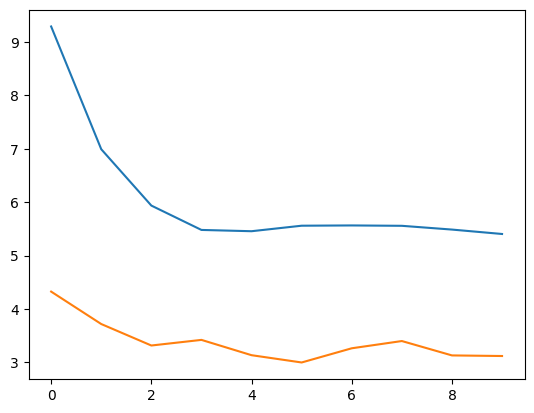

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [41]:
model_train.save_weights("NN_E2E_lo.weights.h5")
model_train.save("NN_E2E_lo.keras")

In [12]:
for i, layer in enumerate(model_train.layers):
    try:
        # Essaie d'obtenir la forme de sortie standard
        shape = layer.output.shape
    except AttributeError:
        # Fallback si layer.output n'est pas direct (cas complexes)
        try:
            shape = layer.output_shape
        except AttributeError:
            shape = "Unknown"
            
    print(f"Index: {i} | Name: {layer.name} | Output Shape: {shape}")

Index: 0 | Name: input_layer | Output Shape: (None, None, None)
Index: 1 | Name: lag_transform_layer | Output Shape: (None, None, None)
Index: 2 | Name: SampleSTD | Output Shape: Unknown
Index: 3 | Name: SampleCov | Output Shape: (None, None, None)
Index: 4 | Name: SpectralCov | Output Shape: Unknown
Index: 5 | Name: DimensionAware | Output Shape: (None, None, 4)
Index: 6 | Name: STDTansformation | Output Shape: (None, None, 1)
Index: 7 | Name: EigenvalueTransformation | Output Shape: (None, None)
Index: 8 | Name: STDInverseNormalization | Output Shape: (None, None, 1)
Index: 9 | Name: TransformedCorrComposition | Output Shape: (None, None, None)
Index: 10 | Name: AddTransformedSTD | Output Shape: (None, None, None)
Index: 11 | Name: PtfWeights | Output Shape: (None, None, 1)


In [1]:
model_train_bis =cm.SimpleModel(
    n_days=None,
    n_assets=None,
    normalize_std='sum',
    hidden_layer_sizes=[8],
    recurrent_layer_sizes=[16],
    outputs=["weights"],

)
model_train_bis.load_weights("NN_E2E_lo.weights.h5")

NameError: name 'cm' is not defined

In [37]:
final_layer = model_train_bis.layers[11] 

cov_tensor = final_layer.input 

cov_extractor = Model(inputs=model_train_bis.input, outputs=cov_tensor)

#### NN end to end cvxpylayer

In [10]:
model_cvxpylayer = cvx.SimpleModel(
    n_days=None,
    n_assets=30,
    normalize_std='sum',
    lag_transform=False,
    hidden_layer_sizes=[8],
    recurrent_layer_sizes=[16],
    outputs=["weights"],
)

model_cvxpylayer.compile(optimizer=tf.keras.optimizers.Adam(2e-3),loss=cl.variance_loss_function, run_eagerly=True)


history =model_cvxpylayer.fit(
    train_dataset_cov,
    validation_data=val_dataset_cov,
    epochs=15,
    steps_per_epoch=500,
    validation_steps=10,
)

Epoch 1/15
  1/500 ━━━━━━━━━━━━━━━━━━━━ 3:54 470ms/step - loss: 7.8073

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:665: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:640: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


500/500 ━━━━━━━━━━━━━━━━━━━━ 92s 184ms/step - loss: 9.9136 - val_loss: 0.0000e+00 - val_variance: 3.9775 - val_weight_mean: 0.0333
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 87s 173ms/step - loss: 8.1083 - val_loss: 0.0000e+00 - val_variance: 3.2416 - val_weight_mean: 0.0333
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 87s 174ms/step - loss: 7.4033 - val_loss: 0.0000e+00 - val_variance: 3.5566 - val_weight_mean: 0.0333
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 87s 175ms/step - loss: 7.1226 - val_loss: 0.0000e+00 - val_variance: 4.2109 - val_weight_mean: 0.0333
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 88s 177ms/step - loss: 6.7895 - val_loss: 0.0000e+00 - val_variance: 3.1535 - val_weight_mean: 0.0333
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 88s 175ms/step - loss: 6.8701 - val_loss: 0.0000e+00 - val_variance: 2.7616 - val_weight_mean: 0.0333
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 87s 175ms/step - loss: 6.5361 - val_loss: 0.0000e+00 - val_variance: 2.8191 - val_weight_mean: 0.0333
Epoch 8/15
500/50

In [16]:
model_cvxpylayer.build(train_dataset_cov.element_spec[0].shape)

model_cvxpylayer.save_weights("NN_E2E_cvx.weights.h5")
model_cvxpylayer.save("NN_E2E_cvx.keras")

In [24]:
cov_model_cvxpylayer = cvx.SimpleModel(
    n_days=None,
    n_assets=30,
    normalize_std='sum',
    lag_transform=False,
    hidden_layer_sizes=[8],
    recurrent_layer_sizes=[16],
    outputs=["TransformedCovarianceMatrix"],
)

cov_model_cvxpylayer.run_eagerly = True


cov_model_cvxpylayer.set_weights(model_cvxpylayer.get_weights())

### Test

In [38]:
test_start, test_end = '2019-01-01', '2023-12-29'

N_stocks_backtest = 30
rebalance_step = 30
window_in = 30
window_out = 30

test_days = get_days_count(test_start, test_end)

In [26]:
test_days = total_days - train_days - val_days
test_returns = clean_returns[train_days+val_days:]

In [34]:
stocks_indices = np.random.choice(total_stocks, size=N_stocks_backtest, replace=False)
test_data = test_returns[:, stocks_indices] # Matrice (T_jours, N_stocks)
T = test_data.shape[0]

current_w_e2e = np.ones(N_stocks_backtest) / N_stocks_backtest
current_w_NN  = np.ones(N_stocks_backtest) / N_stocks_backtest
current_w_MLE = np.ones(N_stocks_backtest) / N_stocks_backtest
current_w_QIS = np.ones(N_stocks_backtest) / N_stocks_backtest
current_w_ew  = np.ones(N_stocks_backtest) / N_stocks_backtest
current_w_NN_cvx  = np.ones(N_stocks_backtest) / N_stocks_backtest

In [35]:
k = 0

for i in range (len(test_data[0])):
    for j in range(len(test_data[1])):

        if test_data[i][j] == 0:
            k += 1
print(f'Nombre de retours quasi nuls dans le backtest : {k}')

print(test_data[0:5])


Nombre de retours quasi nuls dans le backtest : 9
[[ 0.024943  0.023286  0.004494  0.007124  0.009974  0.004009  0.
   0.021529 -0.002083  0.012813  0.017312  0.000234  0.032967  0.022732
  -0.01993   0.014625  0.007321  0.010191  0.009132  0.012199  0.040186
  -0.007903  0.000974  0.028459  0.007465  0.012608  0.014036  0.023711
   0.007151  0.015172]
 [ 0.014243  0.016751  0.000373 -0.006001 -0.009446  0.006606  0.005689
  -0.008172 -0.003035  0.0023    0.019019  0.00797   0.014775 -0.002183
   0.016389 -0.00018   0.009224  0.006644  0.006033 -0.001662  0.03172
   0.009498  0.003699 -0.002222 -0.003626  0.000198  0.012154  0.048338
   0.005917 -0.004891]
 [-0.001769 -0.00746   0.003727  0.011213  0.008453  0.005337  0.008799
   0.003903  0.00019   0.019507  0.004912  0.002791  0.008154 -0.001392
   0.007607  0.001802  0.000277  0.009289 -0.00012   0.007354  0.005124
   0.003338  0.005432 -0.002834  0.000791  0.01067   0.006671  0.001921
   0.011177  0.012562]
 [ 0.010634  0.01378   0

### Backtest

In [ ]:
print(f"Début du Backtest sur {T - window_out - window_in} jours...")

return_simple_NN = []
return_NN_e2e = []
return_MLE = []
return_QIS = []
return_ew = []
return_NN_cvx = []

pos_weights_NN, pos_weights_MLE, pos_weights_QIS, pos_weights_e2e, pos_weights_NN_cvx = [], [], [], [], []
neg_weights_NN, neg_weights_MLE, neg_weights_QIS, neg_weights_e2e, neg_weights_NN_cvx = [], [], [], [], []

for t in range(window_in , T - window_out):

    if (t - window_in) % rebalance_step == 0:
        
        in_sample_data = test_data[t - window_in : t]
        
        #cov_past = np.cov(in_sample_data.T)
        cov_past = LedoitWolf().fit(in_sample_data).covariance_
        
        QIS_past = QIS(in_sample_data.T) 
 
        corr_past = np.corrcoef(in_sample_data.T)
        eig_past, vect_past = np.linalg.eigh(corr_past)
        
        nn_input = eig_past

        #nn_output = corr_cnn.call(nn_input)
        #corr_NN = vect_past @ np.diag(nn_output) @ vect_past.T
        #variances = np.var(in_sample_data, axis=0, ddof = 1)
        #cov_NN = corr_to_cov(corr_NN, variances) 

        input_e2e = in_sample_data.T[np.newaxis, :, :] 

        nn_output_e2e = cov_extractor(input_e2e, training=False)
        output_e2e = nn_output_e2e.numpy().squeeze()
        cov_output_e2e = np.linalg.inv(output_e2e)
        current_w_e2e = weights_long_only_cvx(cov_output_e2e)

        nn_output_NN_cvx = model_cvxpylayer(input_e2e, training=False)
        output_NN_cvx = nn_output_NN_cvx.numpy().squeeze()
        current_w_NN_cvx = output_NN_cvx

    

        #current_w_NN  = weights_long_only(cov_NN)
        current_w_MLE = weights_long_only_cvx(cov_past)
        current_w_QIS = weights_long_only_cvx(QIS_past)
        current_w_ew  = np.ones(N_stocks_backtest) / N_stocks_backtest
    
        #if np.any(current_w_NN < 0):
        #    print(f"ALERTE SHORT à t={t}")

        daily_returns_vector = test_data[t]

        ret_day_e2e = np.dot(current_w_e2e, daily_returns_vector.T)
        #ret_day_NN  = np.dot(current_w_NN,  daily_returns_vector.T)
        ret_day_MLE = np.dot(current_w_MLE, daily_returns_vector.T)
        ret_day_QIS = np.dot(current_w_QIS, daily_returns_vector.T)
        ret_day_ew  = np.dot(current_w_ew,  daily_returns_vector.T)
        ret_day_NN_cvx = np.dot(current_w_NN_cvx, daily_returns_vector.T)
        
        return_NN_e2e.append(ret_day_e2e)
        #return_simple_NN.append(ret_day_NN)
        return_MLE.append(ret_day_MLE)
        return_QIS.append(ret_day_QIS)
        return_ew.append(ret_day_ew)
        return_NN_cvx.append(ret_day_NN_cvx)
        
        current_w_e2e = current_w_e2e * (1 + daily_returns_vector) / (current_w_e2e.T @ (1 + daily_returns_vector))
        #current_w_NN  = current_w_NN  * (1 + daily_returns_vector) / (current_w_NN.T @ (1 + daily_returns_vector))
        current_w_MLE = current_w_MLE * (1 + daily_returns_vector) / (current_w_MLE.T @ (1 + daily_returns_vector))
        current_w_QIS = current_w_QIS * (1 + daily_returns_vector) / (current_w_QIS.T @ (1 + daily_returns_vector))
        current_w_ew  = current_w_ew  * (1 + daily_returns_vector) / (current_w_ew.T @ (1 + daily_returns_vector))
        current_w_NN_cvx = current_w_NN_cvx * (1 + daily_returns_vector) / (current_w_NN_cvx.T @ (1 + daily_returns_vector))

        pos_weights_e2e.append(np.mean(current_w_e2e > 0))
        #pos_weights_NN.append(np.mean(current_w_NN > 0))
        pos_weights_MLE.append(np.mean(current_w_MLE > 0))
        pos_weights_QIS.append(np.mean(current_w_QIS > 0))
        pos_weights_NN_cvx.append(np.mean(current_w_NN_cvx > 0))

        neg_weights_e2e.append(np.mean(current_w_e2e < 0))
        #neg_weights_NN.append(np.mean(current_w_NN < 0))
        neg_weights_MLE.append(np.mean(current_w_MLE < 0))
        neg_weights_QIS.append(np.mean(current_w_QIS < 0))
        neg_weights_NN_cvx.append(np.mean(current_w_NN_cvx < 0))    

    else:

        daily_returns_vector = test_data[t]
        
        ret_day_e2e = np.dot(current_w_e2e, daily_returns_vector.T)
        #ret_day_NN  = np.dot(current_w_NN,  daily_returns_vector.T)
        ret_day_MLE = np.dot(current_w_MLE, daily_returns_vector.T)
        ret_day_QIS = np.dot(current_w_QIS, daily_returns_vector.T)
        ret_day_ew  = np.dot(current_w_ew,  daily_returns_vector.T)
        ret_day_NN_cvx = np.dot(current_w_NN_cvx, daily_returns_vector.T)
        
        return_NN_e2e.append(ret_day_e2e)
        #return_simple_NN.append(float(ret_day_NN))
        return_MLE.append(ret_day_MLE)
        return_QIS.append(ret_day_QIS)
        return_ew.append(ret_day_ew)
        return_NN_cvx.append(ret_day_NN_cvx)

        
        current_w_e2e = current_w_e2e * (1 + daily_returns_vector) / (current_w_e2e.T @ (1 + daily_returns_vector))
        #current_w_NN  = current_w_NN  * (1 + daily_returns_vector) / (current_w_NN.T @ (1 + daily_returns_vector))
        current_w_MLE = current_w_MLE * (1 + daily_returns_vector) / (current_w_MLE.T @ (1 + daily_returns_vector))
        current_w_QIS = current_w_QIS * (1 + daily_returns_vector) / (current_w_QIS.T @ (1 + daily_returns_vector))
        current_w_ew  = current_w_ew  * (1 + daily_returns_vector) / (current_w_ew.T @ (1 + daily_returns_vector))
        current_w_NN_cvx = current_w_NN_cvx * (1 + daily_returns_vector) / (current_w_NN_cvx.T @ (1 + daily_returns_vector))



        pos_weights_e2e.append(np.mean(current_w_e2e > 0))
        #pos_weights_NN.append(np.mean(current_w_NN > 0))
        pos_weights_MLE.append(np.mean(current_w_MLE > 0))
        pos_weights_QIS.append(np.mean(current_w_QIS > 0))
        pos_weights_NN_cvx.append(np.mean(current_w_NN_cvx > 0))

        neg_weights_e2e.append(np.mean(current_w_e2e < 0))
        #neg_weights_NN.append(np.mean(current_w_NN < 0))
        neg_weights_MLE.append(np.mean(current_w_MLE < 0))
        neg_weights_QIS.append(np.mean(current_w_QIS < 0))
        neg_weights_NN_cvx.append(np.mean(current_w_NN_cvx < 0))

        #if np.any(current_w_NN < 0): # np.any est plus sûr que np.mean > 0 pour attraper un seul cas
        #    print(f"ALERTE SHORT à t={t}")

#cum_return_NN = np.cumprod(1 + np.array(return_simple_NN)) 
cum_return_MLE = np.cumprod(1 + np.array(return_MLE))
cum_return_QIS = np.cumprod(1 + np.array(return_QIS))
cum_return_ew = np.cumprod(1 + np.array(return_ew))
cum_return_NN_e2e = np.cumprod(1 + np.array(return_NN_e2e))
cum_return_NN_cvx = np.cumprod(1 + np.array(return_NN_cvx))

#vol_nn = np.std(return_simple_NN) * np.sqrt(252)
vol_mle = np.std(return_MLE) * np.sqrt(252)
vol_qis = np.std(return_QIS) * np.sqrt(252)
vol_ew = np.std(return_ew) * np.sqrt(252)
vol_e2e = np.std(return_NN_e2e) * np.sqrt(252)
vol_nncvx = np.std(return_NN_cvx) * np.sqrt(252)

avg_pos_e2e = np.mean(pos_weights_e2e)
avg_pos_MLE = np.mean(pos_weights_MLE)
#avg_pos_NN = np.mean(pos_weights_NN)
avg_pos_QIS = np.mean(pos_weights_QIS)
avg_pos_NN_cvx = np.mean(pos_weights_NN_cvx)

avg_neg_e2e = np.mean(neg_weights_e2e)
avg_neg_MLE = np.mean(neg_weights_MLE)
#avg_neg_NN = np.mean(neg_weights_NN)
avg_neg_QIS = np.mean(neg_weights_QIS)
avg_neg_NN_cvx = np.mean(neg_weights_NN_cvx)

print("-" * 40)
#print(f"Volatilité Annuelle NN  : {vol_nn:.2%}")
print(f"Volatilité Annuelle MLE : {vol_mle:.2%}")
print(f"Volatilité Annuelle QIS : {vol_qis:.2%}")
print(f"Volatilité Annuelle 1/N : {vol_ew:.2%}")
print(f"Volatilité Annuelle E2E : {vol_e2e:.2%}")
print(f"Volatilité Annuelle NN CVX : {vol_nncvx:.2%}")
print("-" * 40)
print(f"% Moyen d'actifs sélectionnés (Poids > 0) :")
print(f"  - pourcentage de long E2E : {avg_pos_e2e:.1%}")
print(f"  - pourcentage de long MLE : {avg_pos_MLE:.1%}")
#print(f"  - pourcentage de long NN  : {avg_pos_NN:.1%}")
print(f"  - pourcentage de long QIS : {avg_pos_QIS:.1%}")
print(f"  - pourcentage de long NN CVX : {avg_pos_NN_cvx:.1%}")
print("-" * 40)
print(f"% Moyen d'actifs sélectionnés (Poids < 0) :")
print(f"  - pourcentage de short E2E : {avg_neg_e2e:.1%}")
print(f"  - pourcentage de short MLE : {avg_neg_MLE:.1%}")
#print(f"  - pourcentage de short NN  : {avg_neg_NN:.1%}")
print(f"  - pourcentage de short QIS : {avg_neg_QIS:.1%}")
print(f"  - pourcentage de short NN CVX : {avg_neg_NN_cvx:.1%}")

# Plot
plt.figure(figsize=(12, 6))
#plt.plot(cum_return_NN, label=f'Simple NN (Vol: {vol_nn:.1%})', linewidth=2)
plt.plot(cum_return_MLE, label=f'MLE (Vol: {vol_mle:.1%})', linestyle='--')
plt.plot(cum_return_ew, label=f'Equi-weighted (Vol: {vol_ew:.1%})', alpha=0.5)
plt.plot(cum_return_QIS, label=f'QIS (Vol: {vol_qis:.1%})', linestyle='-.')
plt.plot(cum_return_NN_e2e, label=f'End to End NN (Vol: {vol_e2e:.1%})', linestyle=':')
plt.plot(cum_return_NN_cvx, label=f'End to End NN CVXPY (Vol: {vol_nncvx:.1%})', linestyle='-')
plt.yscale('log') 
plt.title('Backtest: Minimum Variance Strategy')
plt.ylabel('Cumulative Return')
plt.xlabel('Days')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Début du Backtest sur 2463 jours...


NameError: name 'cov_extractor' is not defined

In [ ]:
# Paramètre de taux sans risque (annualisé)
risk_free = 0.00 # Exemple à 2%

def calculate_sharpe(returns, vol, rf):
    ann_return = np.mean(returns) * 252
    return (ann_return - rf) / vol

# Calcul des Sharpe Ratios
sharpe_mle = calculate_sharpe(return_MLE, vol_mle, risk_free)
sharpe_qis = calculate_sharpe(return_QIS, vol_qis, risk_free)
sharpe_ew = calculate_sharpe(return_ew, vol_ew, risk_free)
sharpe_e2e = calculate_sharpe(return_NN_e2e, vol_e2e, risk_free)
sharpe_nncvx = calculate_sharpe(return_NN_cvx, vol_nncvx, risk_free)

print("-" * 40)
print(f"Sharpe Ratio (Rf={risk_free:.1%}) :")
print(f"  - Sharpe MLE    : {sharpe_mle:.2f}")
print(f"  - Sharpe QIS    : {sharpe_qis:.2f}")
print(f"  - Sharpe 1/N    : {sharpe_ew:.2f}")
print(f"  - Sharpe E2E    : {sharpe_e2e:.2f}")
print(f"  - Sharpe NN CVX : {sharpe_nncvx:.2f}")
print("-" * 40)



----------------------------------------
Sharpe Ratio (Rf=0.0%) :
  - Sharpe MLE    : 0.34
  - Sharpe QIS    : 0.45
  - Sharpe 1/N    : 0.67
  - Sharpe E2E    : 0.75
  - Sharpe NN CVX : 0.48
----------------------------------------


In [ ]:
n_samples = 200
N_stocks_backtest = 30

list_std_NN_lo = []
list_std_QIS = []
list_std_MLE = []
list_std_NN_cvx = []

list_sharpe_NN_lo = []
list_sharpe_QIS = []
list_sharpe_MLE = []
list_sharpe_NN_cvx = []

for _ in range(n_samples): 

    stocks_indices = np.random.choice(total_stocks, size=N_stocks_backtest, replace=False)
    test_data = test_returns[:, stocks_indices] # Matrice (T_jours, N_stocks)
    T = test_data.shape[0]

    current_w_NN_lo  = np.ones(N_stocks_backtest) / N_stocks_backtest
    current_w_MLE = np.ones(N_stocks_backtest) / N_stocks_backtest
    current_w_QIS = np.ones(N_stocks_backtest) / N_stocks_backtest
    current_w_NN_cvx  = np.ones(N_stocks_backtest) / N_stocks_backtest

    return_NN_lo = []
    return_NN_cvx = []
    return_MLE = []
    return_QIS = []

    for t in range(window_in , T - window_out):

        if (t - window_in) % rebalance_step == 0:
        
            in_sample_data = test_data[t - window_in : t]
        
            cov_past = np.cov(in_sample_data.T)
        
            QIS_past = QIS(in_sample_data.T) 
            corr_past = np.corrcoef(in_sample_data.T)
            eig_past, vect_past = np.linalg.eigh(corr_past)
        
            nn_input = eig_past
            input_nn = in_sample_data.T[np.newaxis, :, :] 

            nn_output_lo = cov_extractor(input_nn, training=False)
            output_lo = nn_output_lo.numpy().squeeze()
            cov_output_lo = np.linalg.inv(output_lo)
            current_w_NN_lo = weights_long_only_cvx(cov_output_lo)

            nn_output_NN_cvx = model_cvxpylayer(input_nn, training=False)
            output_NN_cvx = nn_output_NN_cvx.numpy().squeeze()
            current_w_NN_cvx = output_NN_cvx

            current_w_MLE = weights_long_only_cvx(cov_past)
            current_w_QIS = weights_long_only_cvx(QIS_past)

            daily_returns_vector = test_data[t]

            ret_day_lo = np.dot(current_w_NN_lo, daily_returns_vector.T)
            ret_day_MLE = np.dot(current_w_MLE, daily_returns_vector.T)
            ret_day_QIS = np.dot(current_w_QIS, daily_returns_vector.T)
            ret_day_NN_cvx = np.dot(current_w_NN_cvx, daily_returns_vector.T)
        
            return_NN_lo.append(ret_day_lo)
            return_MLE.append(ret_day_MLE)
            return_QIS.append(ret_day_QIS)
            return_NN_cvx.append(ret_day_NN_cvx)
        
            current_w_NN_lo = current_w_NN_lo * (1 + daily_returns_vector) / (current_w_NN_lo.T @ (1 + daily_returns_vector))
            current_w_MLE = current_w_MLE * (1 + daily_returns_vector) / (current_w_MLE.T @ (1 + daily_returns_vector))
            current_w_QIS = current_w_QIS * (1 + daily_returns_vector) / (current_w_QIS.T @ (1 + daily_returns_vector))
            current_w_NN_cvx = current_w_NN_cvx * (1 + daily_returns_vector) / (current_w_NN_cvx.T @ (1 + daily_returns_vector))    

        else:

            daily_returns_vector = test_data[t]

            ret_day_NN_lo = np.dot(current_w_NN_lo, daily_returns_vector.T)
            ret_day_MLE = np.dot(current_w_MLE, daily_returns_vector.T)
            ret_day_QIS = np.dot(current_w_QIS, daily_returns_vector.T)
            ret_day_NN_cvx = np.dot(current_w_NN_cvx, daily_returns_vector.T)
        
            return_NN_lo.append(ret_day_NN_lo)
            return_MLE.append(ret_day_MLE)
            return_QIS.append(ret_day_QIS)
            return_NN_cvx.append(ret_day_NN_cvx)
        
            current_w_NN_lo = current_w_NN_lo * (1 + daily_returns_vector) / (current_w_NN_lo.T @ (1 + daily_returns_vector))
            current_w_MLE = current_w_MLE * (1 + daily_returns_vector) / (current_w_MLE.T @ (1 + daily_returns_vector))
            current_w_QIS = current_w_QIS * (1 + daily_returns_vector) / (current_w_QIS.T @ (1 + daily_returns_vector))
            current_w_NN_cvx = current_w_NN_cvx * (1 + daily_returns_vector) / (current_w_NN_cvx.T @ (1 + daily_returns_vector))  

 
    cum_return_MLE = np.cumprod(1 + np.array(return_MLE))
    cum_return_QIS = np.cumprod(1 + np.array(return_QIS))
    cum_return_NN_lo = np.cumprod(1 + np.array(return_NN_lo))
    cum_return_NN_cvx = np.cumprod(1 + np.array(return_NN_cvx))

    vol_mle = np.std(return_MLE) * np.sqrt(252)
    vol_qis = np.std(return_QIS) * np.sqrt(252)
    vol_nnlo = np.std(return_NN_lo) * np.sqrt(252)
    vol_nncvx = np.std(return_NN_cvx) * np.sqrt(252)

    list_std_NN_lo.append(vol_nnlo)
    list_std_MLE.append(vol_mle)
    list_std_NN_cvx.append(vol_nncvx)
    list_std_QIS.append(vol_qis)
    
    list_sharpe_NN_lo.append(calculate_sharpe(return_NN_lo, vol_nnlo, risk_free))
    list_sharpe_MLE.append(calculate_sharpe(return_MLE, vol_mle, risk_free))
    list_sharpe_NN_cvx.append(calculate_sharpe(return_NN_cvx, vol_nncvx, risk_free))
    list_sharpe_QIS.append(calculate_sharpe(return_QIS, vol_qis, risk_free))

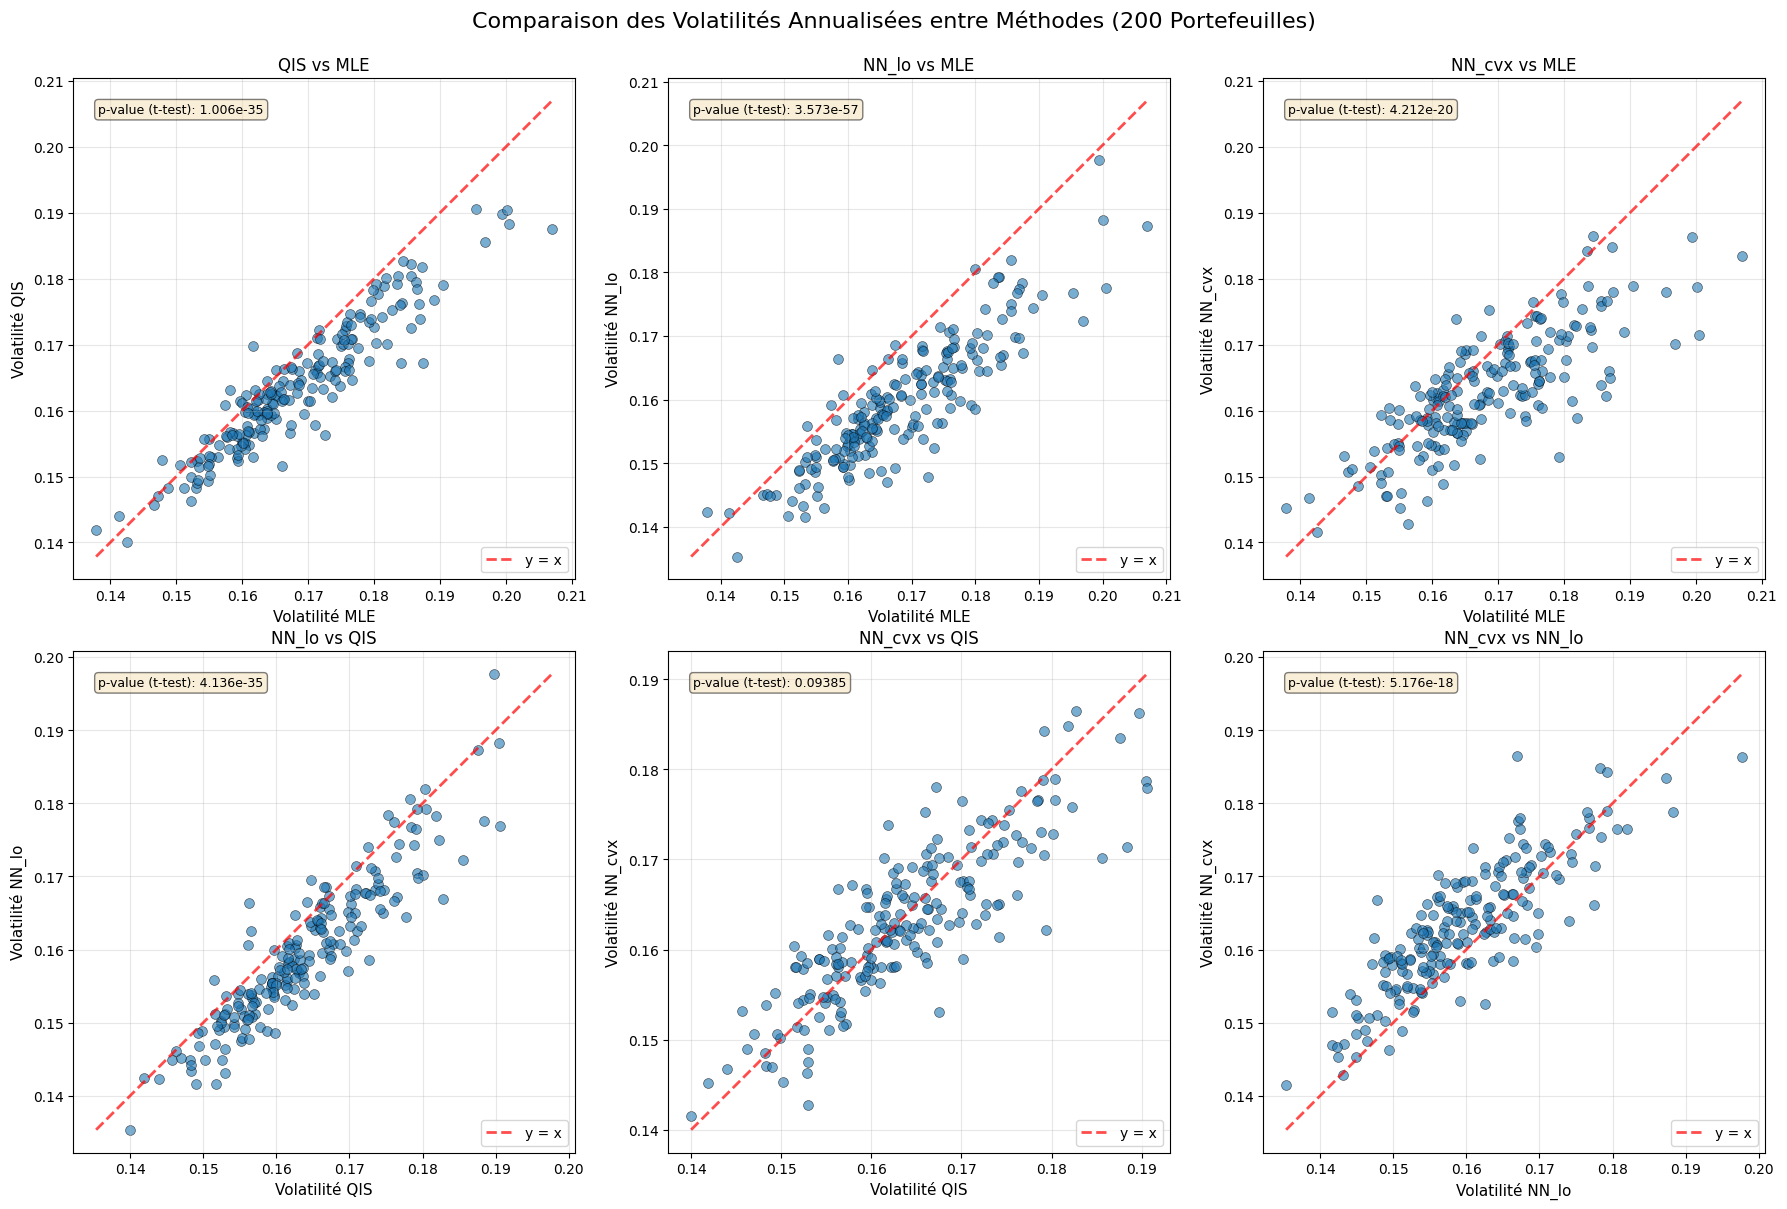

Comparaison          Diff moy     t-test p     Significatif   
------------------------------------------------------------------------------------------
QIS vs MLE      -0.004592    0.000000    ***            
NN_lo vs MLE      -0.008793    0.000000    ***            
NN_cvx vs MLE      -0.005206    0.000000    ***            
NN_lo vs QIS      -0.004201    0.000000    ***            
NN_cvx vs QIS      -0.000614    0.093852    ns             
NN_cvx vs NN_lo    +0.003587    0.000000    ***            


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Vos listes : list_std_MLE, list_std_QIS, list_std_NN_lo, list_std_NN_cvx

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Comparaison des Volatilités Annualisées entre Méthodes (200 Portefeuilles)', fontsize=16, y=1.00)

comparisons = [
    ('MLE', 'QIS', list_std_MLE, list_std_QIS, axes[0, 0]),
    ('MLE', 'NN_lo', list_std_MLE, list_std_NN_lo, axes[0, 1]),
    ('MLE', 'NN_cvx', list_std_MLE, list_std_NN_cvx, axes[0, 2]),
    ('QIS', 'NN_lo', list_std_QIS, list_std_NN_lo, axes[1, 0]),
    ('QIS', 'NN_cvx', list_std_QIS, list_std_NN_cvx, axes[1, 1]),
    ('NN_lo', 'NN_cvx', list_std_NN_lo, list_std_NN_cvx, axes[1, 2])
]

for x_label, y_label, x_data, y_data, ax in comparisons:
    x_arr = np.array(x_data)
    y_arr = np.array(y_data)
    
    # Tests statistiques
    t_stat, p_value_paired = stats.ttest_rel(y_arr, x_arr)
    
    # Tracé des points
    ax.scatter(x_data, y_data, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    
    # Droite y = x
    min_val = min(min(x_data), min(y_data))
    max_val = max(max(x_data), max(y_data))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y = x', alpha=0.7)
    
    # Ajout des p-values sur le graphique
    textstr = f'p-value (t-test): {p_value_paired:.4g}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Configuration
    ax.set_xlabel(f'Volatilité {x_label}', fontsize=11)
    ax.set_ylabel(f'Volatilité {y_label}', fontsize=11)
    ax.set_title(f'{y_label} vs {x_label}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# Tableau récapitulatif
print("="*90)
print(f"{'Comparaison':<20} {'Diff moy':<12} {'t-test p':<12} {'Significatif':<15}")
print("-"*90)

for x_label, y_label, x_data, y_data, _ in comparisons:
    x_arr = np.array(x_data)
    y_arr = np.array(y_data)
    mean_diff = np.mean(y_arr - x_arr)
    
    t_stat, p_value_paired = stats.ttest_rel(y_arr, x_arr)
    
    sig = '***' if p_value_paired < 0.001 else '**' if p_value_paired < 0.01 else '*' if p_value_paired < 0.05 else 'ns'
    
    print(f"{y_label} vs {x_label:<8} {mean_diff:+.6f}    {p_value_paired:.6f}    {sig:<15}")

print("="*90)


In [ ]:
mean_sharpe = {
    'NN Long-Only': np.mean(list_sharpe_NN_lo),
    'MLE': np.mean(list_sharpe_MLE),
    'NN + CVX': np.mean(list_sharpe_NN_cvx),
    'QIS': np.mean(list_sharpe_QIS)
}

# Créer un DataFrame
df_sharpe = pd.DataFrame(list(mean_sharpe.items()), columns=['Strategy', 'Mean Sharpe Ratio'])

# Afficher le tableau
print(df_sharpe)

# Optionnel : formater les chiffres
df_sharpe['Mean Sharpe Ratio'] = df_sharpe['Mean Sharpe Ratio'].round(4)
print(df_sharpe)